# btvNano Exercise and Analysis 

Rather than using legacy `ROOT` in C++ for analysis, let's try out with `UPROOT` in python. The C++ analysis will also be done simulataneously to compare the results. The btvNano samples are created using the btvNano customisations referred from [PFNano production](https://github.com/cms-jet/PFNano/tree/106x).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import uproot as rt
import mplhep as hep
import mplhep.cms as cmshep
import awkward as ak

In [38]:
plt.style.use(hep.style.CMS)
plt.rcParams.update({
    "font.size": 18,
    "axes.labelsize": 18,
    "axes.titlesize": 18,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 18
})

def make_hist(data, bins, range, xlabel, ylabel, title, label, fname=None, logy=False):
    histo, edges = np.histogram(data, bins=bins, range=range)
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    hep.histplot(histo, edges, histtype="step", label=label, ax=ax)
    hep.cms.text("Open Data", ax=ax, loc=0)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title, loc="right")
    ax.legend()
    if logy:
        ax.set_yscale("log")
    if fname:
        plt.savefig(fname)
    plt.show()

## TTToSemiLeptonic_TuneCP5_13TeV_powheg-pythia8

### AK4-Jets
Here are the variables for `JetPFCandsAK4_btag`. The description of each of these variables will be given below:

- `JetPFCandsAK4_btagEtaRel`: $\eta_{rel}$ of a PF candidate with respect to the associated jet measures how much the candidate deviates from the jet axis. Larger values for b/c-jets and smaller values for light jets.

- `JetPFCandsAK4_btagPtRatio`: This refers to the ratio of the PFCandidates' pT to their associated Jet's pT. If the ratio is close to 1, the candidate likely carries most of the jet's momentum possibly a **B-hadron** or **C-hadron**. 

- `JetPDCandsAK4_jetIdx`: This is an index array for PFCands which corresponds to the index of the jet they are associated with. For example: If in an event, there are 3 jets and a PFCandidate belongs to jet#3, then the `JetPFCandsAK4_jetIdx` for the candidate will be 3.

- `JetPFCandsAK4_btagPParRatio`: This is a measure of how much the PFCandidates along the jet direction (an angle). If values are closer to 1 then the jet is like to be a light jet. Whilst b-jets and c-jets will have a value less than 1.

- `JetPFCandsAK4_btagSip3dSig`: (Signed Impact Parameter Significance) This measure quantifies how significantly displaced a PFCandidate is from the primary vertex. B-hadrons have the large positive values, C-Hadrons will have intermediate positive values while light jets have low positive values (or near 0). If negative values then the PFCandidate track crosses before the primary vertex and is likely a mismeasurement. 

- `JetPFCandsAK4_btagSip3dVal`: (Signed Impact Parameter value) This measure gives the signed 3D distance of a PFCandidate track from the primary vertex - how far a decay product originates from the primary vertex. 

- `JetPFCandsAK4_candIdx:` This refers to the index of PFCandidate in the global PFCandidate collection.

> **Impact Parameter**: Refers to the minimum distance between the track and the Primary Vertex(PV). The 3D-Impact Parameter is the full spatial distance between the PV and the track at its point of closest approach. This is given by $d = \sqrt{d^{2}_{xy} + d^{2}_{z}}$

> **Primary Vertex**: Reconstructed collision point of the main proton-proton interaction in an event.


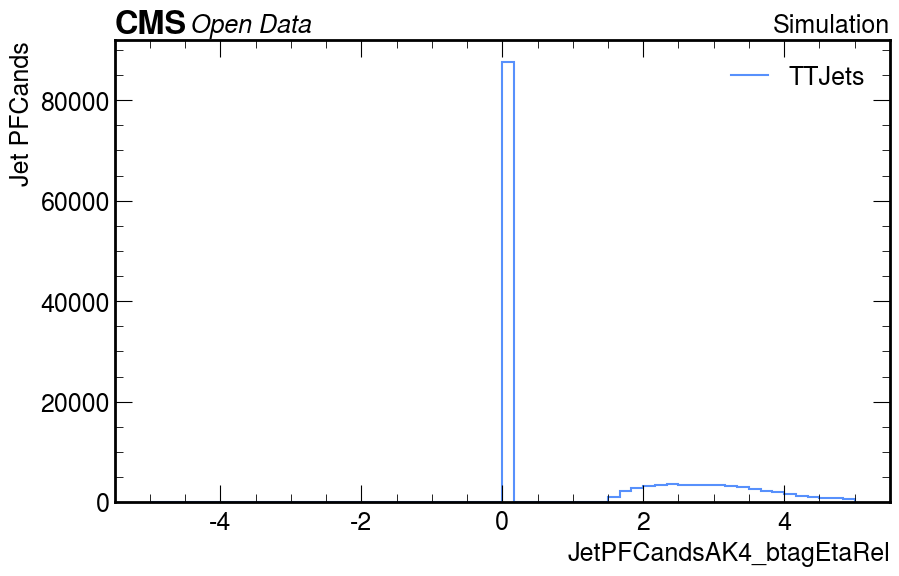

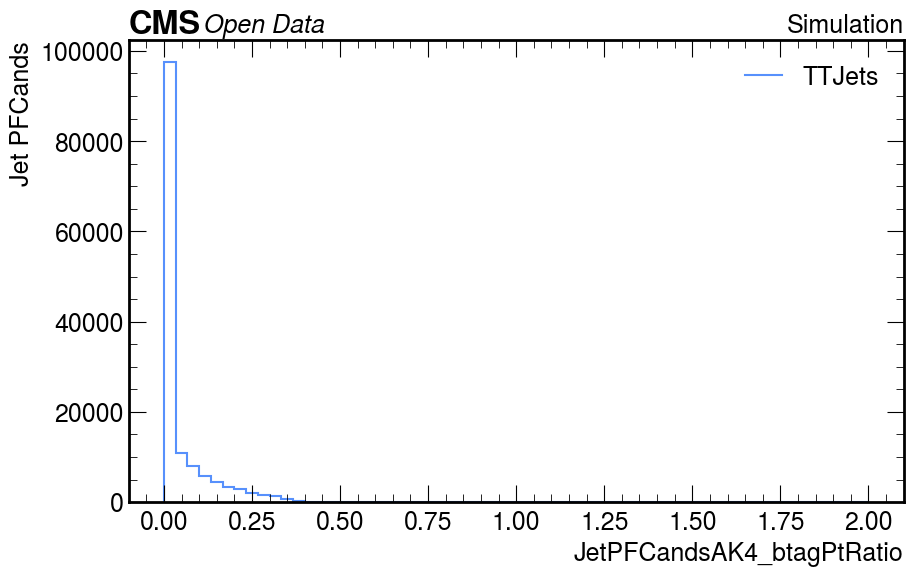

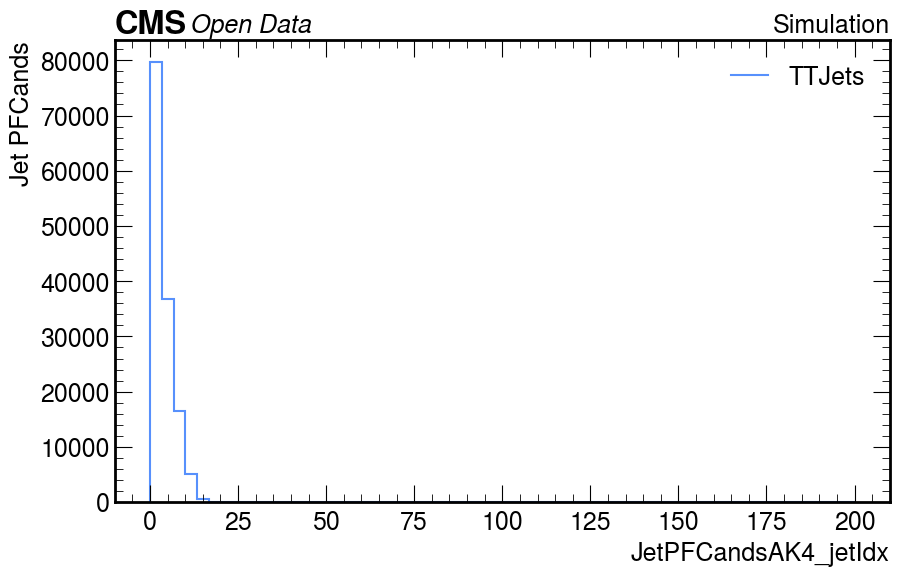

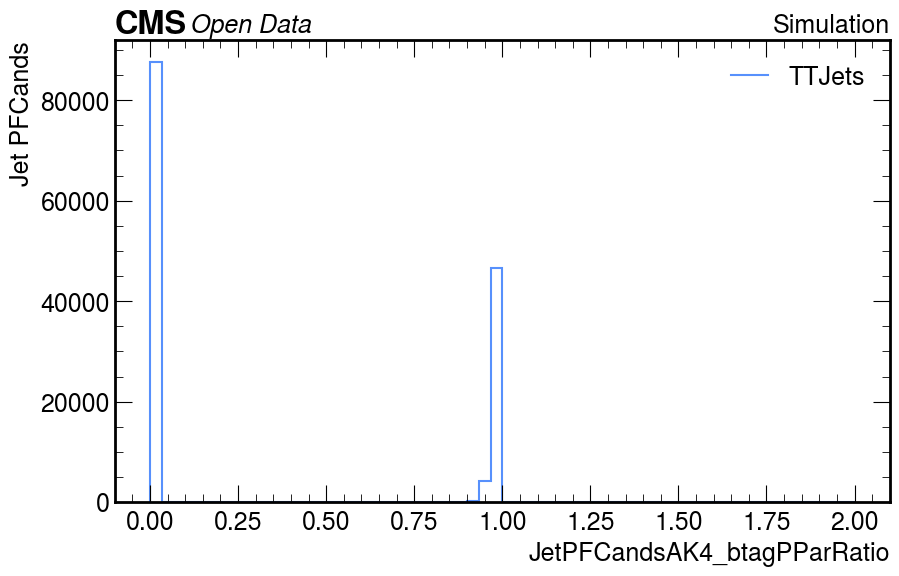

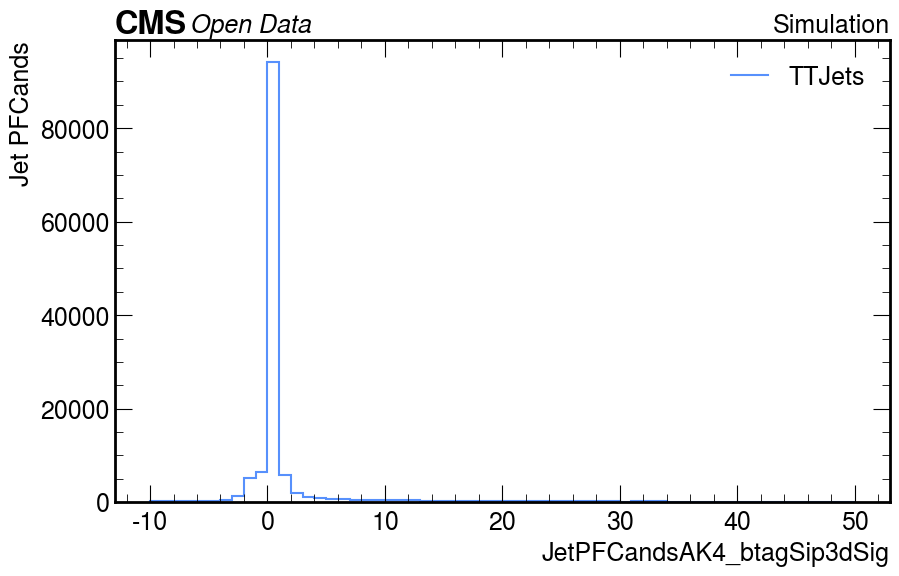

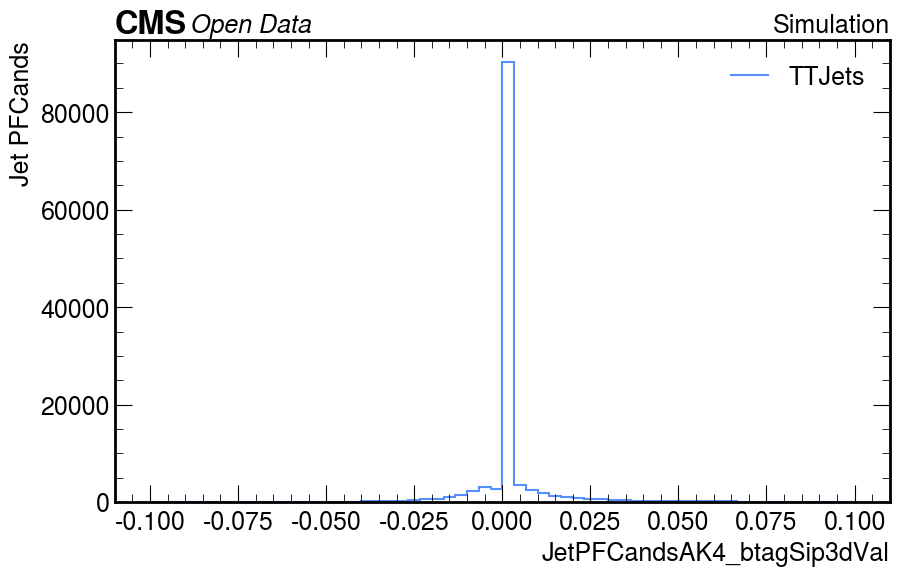

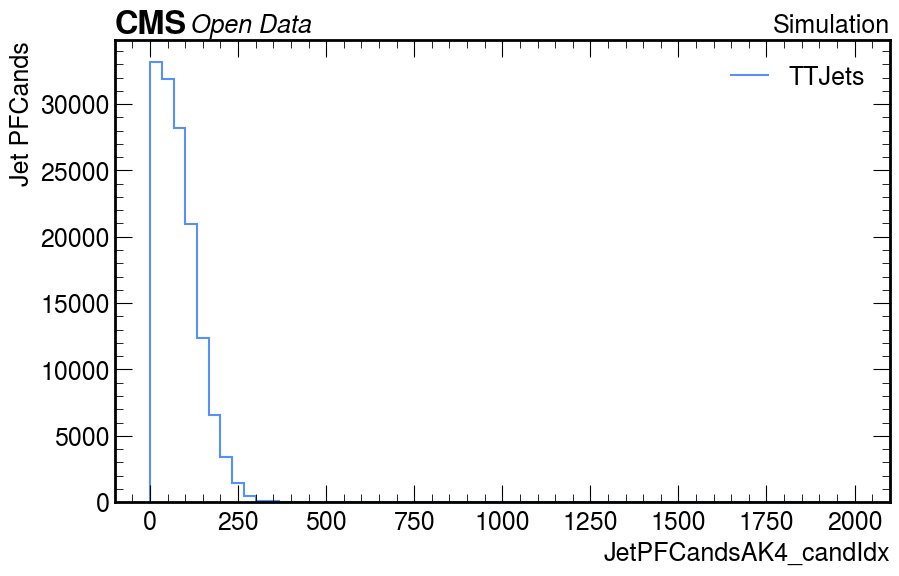

In [39]:
btvNano_file2 = rt.open("../datasets/nano106X_on_mini106X_2017_mc_NANOAOD_TTToSemiLeptonic.root")
btvNanoEvents_2 = btvNano_file2["Events"]

JetPFCandsAK4 = btvNanoEvents_2.arrays(["JetPFCandsAK4_btagEtaRel", "JetPFCandsAK4_btagPtRatio", "JetPFCandsAK4_jetIdx", "JetPFCandsAK4_btagPParRatio", "JetPFCandsAK4_btagSip3dSig", "JetPFCandsAK4_btagSip3dVal", "JetPFCandsAK4_candIdx"], library="ak")

JetPFCandsAK4_btagEtaRel = ak.flatten(JetPFCandsAK4["JetPFCandsAK4_btagEtaRel"])
JetPFCandsAK4_btagPtRatio = ak.flatten(JetPFCandsAK4["JetPFCandsAK4_btagPtRatio"])
JetPFCandsAK4_jetIdx = ak.flatten(JetPFCandsAK4["JetPFCandsAK4_jetIdx"])
JetPFCandsAK4_btagPParRatio = ak.flatten(JetPFCandsAK4["JetPFCandsAK4_btagPParRatio"])
JetPFCandsAK4_btagSip3dSig = ak.flatten(JetPFCandsAK4["JetPFCandsAK4_btagSip3dSig"])
JetPFCandsAK4_btagSip3dVal = ak.flatten(JetPFCandsAK4["JetPFCandsAK4_btagSip3dVal"])
JetPFCandsAK4_candIdx = ak.flatten(JetPFCandsAK4["JetPFCandsAK4_candIdx"])

make_hist(JetPFCandsAK4_btagEtaRel, bins=60, range=(-5,5), xlabel=r"JetPFCandsAK4_btagEtaRel", ylabel="Jet PFCands", title="Simulation", label="TTJets", fname="TTToSemiLeptonic/JetPFCandsAK4_btagEtaRel.png", logy=False)
make_hist(JetPFCandsAK4_btagPtRatio, bins=60, range=(0,2), xlabel=r"JetPFCandsAK4_btagPtRatio", ylabel="Jet PFCands", title="Simulation", label="TTJets", fname="TTToSemiLeptonic/JetPFCandsAK4_btagPtRatio.png", logy=False)
make_hist(JetPFCandsAK4_jetIdx, bins=60, range=(0,200), xlabel=r"JetPFCandsAK4_jetIdx", ylabel="Jet PFCands", title="Simulation", label="TTJets", fname="TTToSemiLeptonic/JetPFCandsAK4_jetIdx.png", logy=False)
make_hist(JetPFCandsAK4_btagPParRatio, bins=60, range=(0,2), xlabel=r"JetPFCandsAK4_btagPParRatio", ylabel="Jet PFCands", title="Simulation", label="TTJets", fname="TTToSemiLeptonic/JetPFCandsAK4_btagPParRatio.png", logy=False)
make_hist(JetPFCandsAK4_btagSip3dSig, bins=60, range=(-10,50), xlabel=r"JetPFCandsAK4_btagSip3dSig", ylabel="Jet PFCands", title="Simulation", label="TTJets", fname="TTToSemiLeptonic/JetPFCandsAK4_btagSip3dSig.png", logy=False)
make_hist(JetPFCandsAK4_btagSip3dVal, bins=60, range=(-0.1,0.1), xlabel=r"JetPFCandsAK4_btagSip3dVal", ylabel="Jet PFCands", title="Simulation", label="TTJets", fname="TTToSemiLeptonic/JetPFCandsAK4_btagSip3dVal.png", logy=False)
make_hist(JetPFCandsAK4_candIdx, bins=60, range=(0,2000), xlabel=r"JetPFCandsAK4_candIdx", ylabel="Jet PFCands", title="Simulation", label="TTJets", fname="TTToSemiLeptonic/JetPFCandsAK4_candIdx.png", logy=False)

## AK8 Jets

Here are the variables for JetPFCandsAK8_btag.

- `JetPFCandsAK8_btagEtaRel`: $\eta_{rel}$ of a PF candidate with respect to the associated jet measures how much the candidate deviates from the jet axis. Larger values for b/c-jets and smaller values for light jets.

- `JetPFCandsAK8_btagPtRatio`: This refers to the ratio of the PFCandidates' pT to their associated Jet's pT. If the ratio is close to 1, the candidate likely carries most of the jet's momentum possibly a **B-hadron** or **C-hadron**. 

- `JetPDCandsAK8_jetIdx`: This is an index array for PFCands which corresponds to the index of the jet they are associated with. For example: If in an event, there are 3 jets and a PFCandidate belongs to jet#3, then the `JetPFCandsAK8_jetIdx` for the candidate will be 3.

- `JetPFCandsAK8_btagPParRatio`: This is a measure of how much the PFCandidates along the jet direction (an angle). If values are closer to 1 then the jet is like to be a light jet. Whilst b-jets and c-jets will have a value less than 1.

- `JetPFCandsAK8_btagSip3dSig`: (Signed Impact Parameter Significance) This measure quantifies how significantly displaced a PFCandidate is from the primary vertex. B-hadrons have the large positive values, C-Hadrons will have intermediate positive values while light jets have low positive values (or near 0). If negative values then the PFCandidate track crosses before the primary vertex and is likely a mismeasurement. 

- `JetPFCandsAK8_btagSip3dVal`: (Signed Impact Parameter value) This measure gives the signed 3D distance of a PFCandidate track from the primary vertex - how far a decay product originates from the primary vertex. 

- `JetPFCandsAK8_candIdx:` This refers to the index of PFCandidate in the global PFCandidate collection.

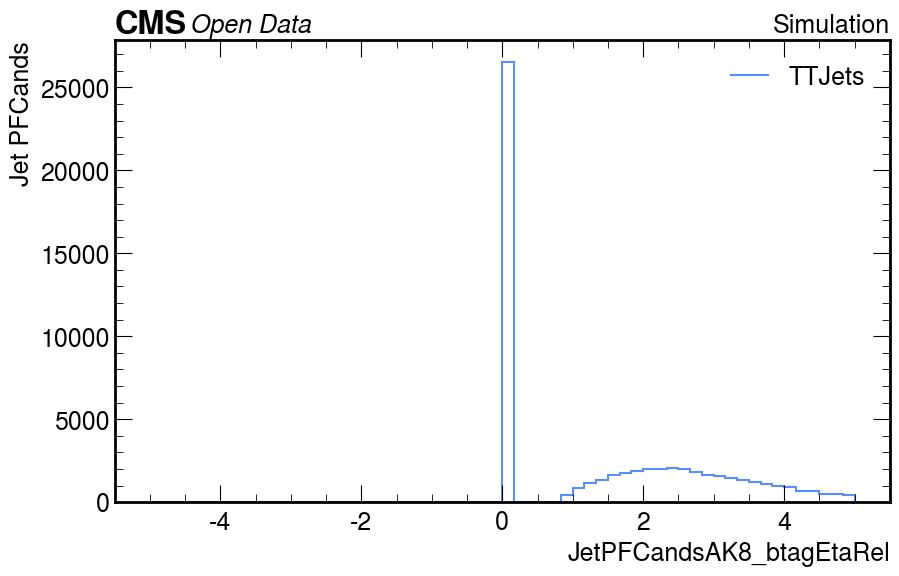

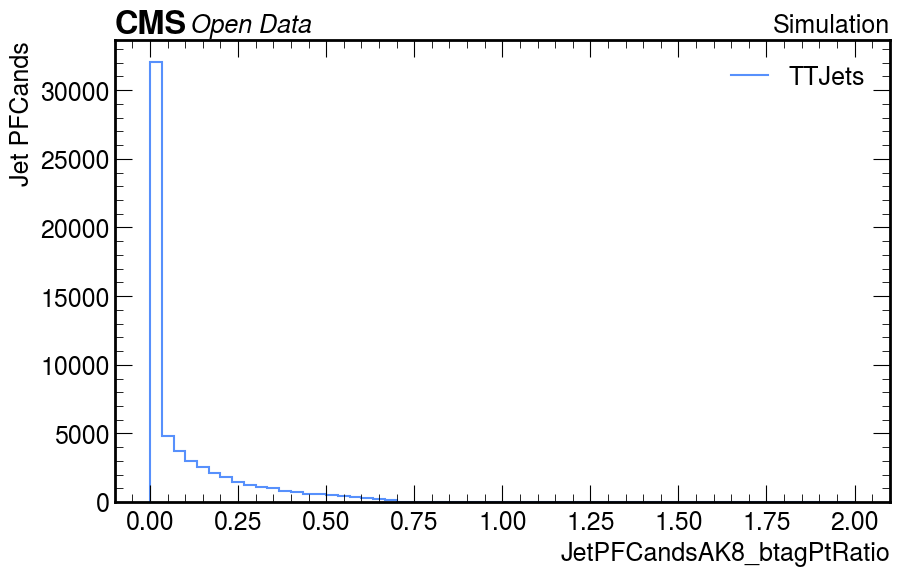

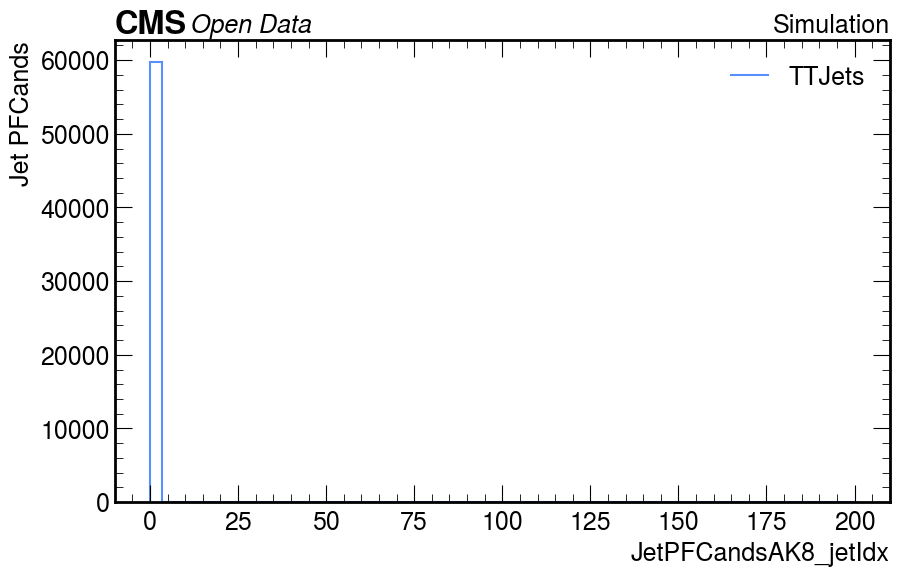

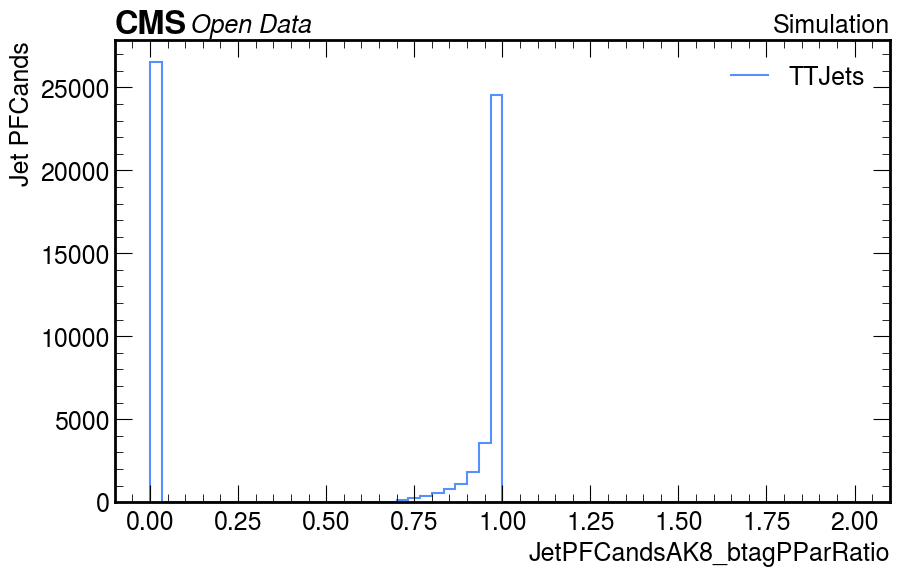

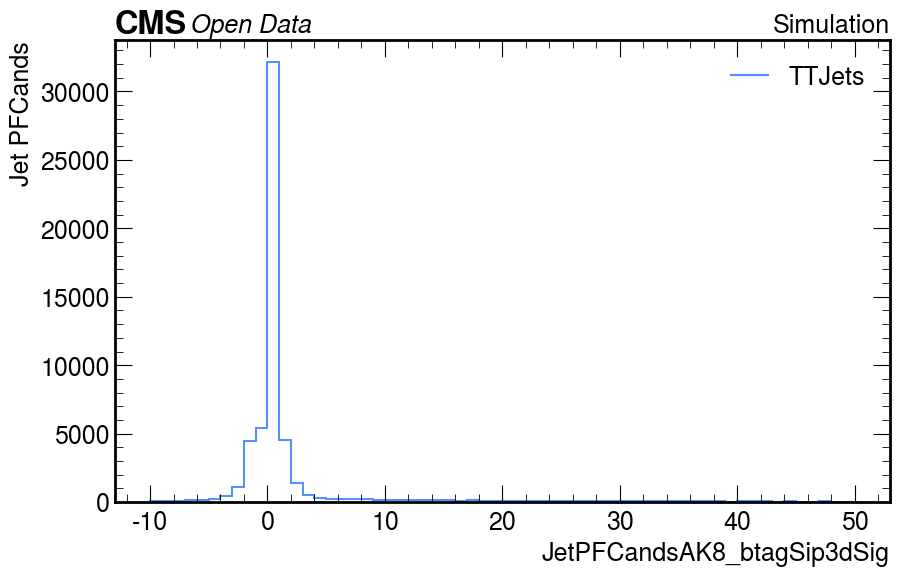

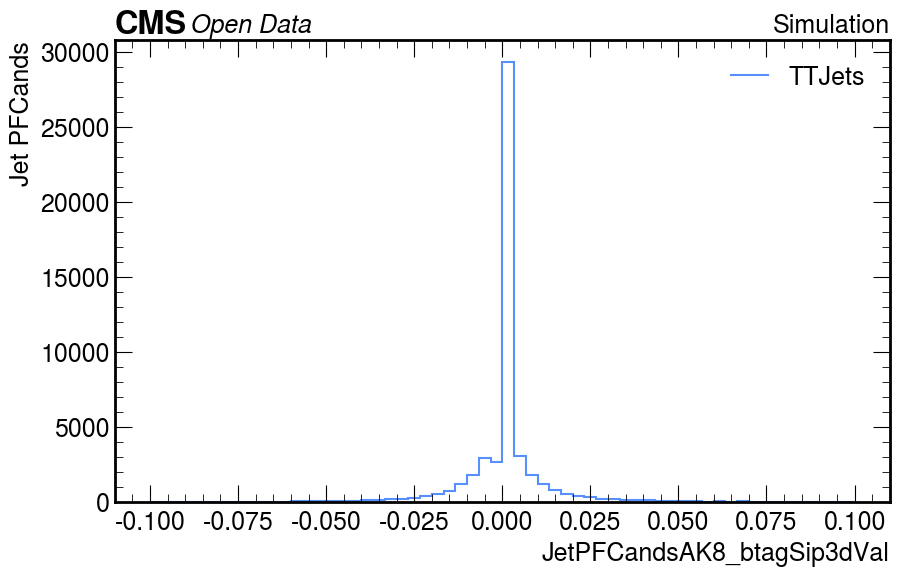

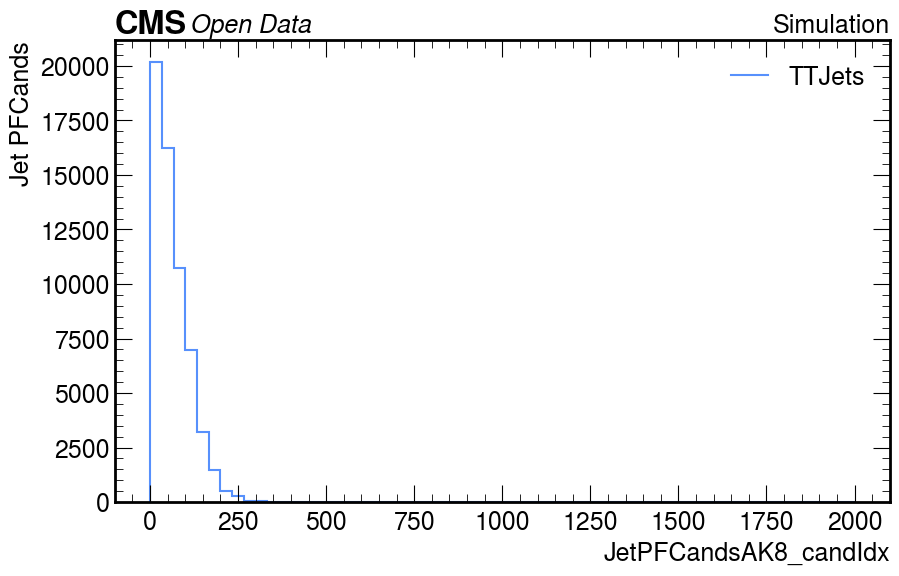

In [40]:
JetPFCandsAK8 = btvNanoEvents.arrays(["JetPFCandsAK8_btagEtaRel", "JetPFCandsAK8_btagPtRatio", "JetPFCandsAK8_jetIdx", "JetPFCandsAK8_btagPParRatio", "JetPFCandsAK8_btagSip3dSig", "JetPFCandsAK8_btagSip3dVal", "JetPFCandsAK8_candIdx"], library="ak")

JetPFCandsAK8_btagEtaRel = ak.flatten(JetPFCandsAK8["JetPFCandsAK8_btagEtaRel"])
JetPFCandsAK8_btagPtRatio = ak.flatten(JetPFCandsAK8["JetPFCandsAK8_btagPtRatio"])
JetPFCandsAK8_jetIdx = ak.flatten(JetPFCandsAK8["JetPFCandsAK8_jetIdx"])
JetPFCandsAK8_btagPParRatio = ak.flatten(JetPFCandsAK8["JetPFCandsAK8_btagPParRatio"])
JetPFCandsAK8_btagSip3dSig = ak.flatten(JetPFCandsAK8["JetPFCandsAK8_btagSip3dSig"])
JetPFCandsAK8_btagSip3dVal = ak.flatten(JetPFCandsAK8["JetPFCandsAK8_btagSip3dVal"])
JetPFCandsAK8_candIdx = ak.flatten(JetPFCandsAK8["JetPFCandsAK8_candIdx"])

make_hist(JetPFCandsAK8_btagEtaRel, bins=60, range=(-5,5), xlabel=r"JetPFCandsAK8_btagEtaRel", ylabel="Jet PFCands", title="Simulation", label="TTJets", fname="TTToSemiLeptonic/JetPFCandsAK8_btagEtaRel.png", logy=False)
make_hist(JetPFCandsAK8_btagPtRatio, bins=60, range=(0,2), xlabel=r"JetPFCandsAK8_btagPtRatio", ylabel="Jet PFCands", title="Simulation", label="TTJets", fname="TTToSemiLeptonic/JetPFCandsAK8_btagPtRatio.png", logy=False)
make_hist(JetPFCandsAK8_jetIdx, bins=60, range=(0,200), xlabel=r"JetPFCandsAK8_jetIdx", ylabel="Jet PFCands", title="Simulation", label="TTJets", fname="TTToSemiLeptonic/JetPFCandsAK8_jetIdx.png", logy=False) 
make_hist(JetPFCandsAK8_btagPParRatio, bins=60, range=(0,2), xlabel=r"JetPFCandsAK8_btagPParRatio", ylabel="Jet PFCands", title="Simulation", label="TTJets", fname="TTToSemiLeptonic/JetPFCandsAK8_btagPParRatio.png", logy=False)
make_hist(JetPFCandsAK8_btagSip3dSig, bins=60, range=(-10,50), xlabel=r"JetPFCandsAK8_btagSip3dSig", ylabel="Jet PFCands", title="Simulation", label="TTJets", fname="TTToSemiLeptonic/JetPFCandsAK8_btagSip3dSig.png", logy=False)
make_hist(JetPFCandsAK8_btagSip3dVal, bins=60, range=(-0.1,0.1), xlabel=r"JetPFCandsAK8_btagSip3dVal", ylabel="Jet PFCands", title="Simulation", label="TTJets", fname="TTToSemiLeptonic/JetPFCandsAK8_btagSip3dVal.png", logy=False)
make_hist(JetPFCandsAK8_candIdx, bins=60, range=(0,2000), xlabel=r"JetPFCandsAK8_candIdx", ylabel="Jet PFCands", title="Simulation", label="TTJets", fname="TTToSemiLeptonic/JetPFCandsAK8_candIdx.png", logy=False)

## JetPFCandidates

Here are the variables for `JetPFCands`:

- `JetPFCands_charge`: Charge of PFCandidates within a jet.

- `JetPFCands_eta`: Pseudorapidity of PFCandidates within a jet.

- `JetPFCands_phi`: Polar angle of PFCandidates within a jet.

- `JetPFCands_pt`: Transverse momentum of PFCandidates within a jet.

- `JetPFCands_mass`: Mass of PFCandidates within a jet.

- `JetPFCands_puppiWeight`: Measure of PFCandidate's contribution to the jet, after correcting for pileup contamination. Values near 1 means the candidate is from a hard scatter and values near 0 means pileup.

- `JetPFCands_puppiWeightNoLep`: PUPPI weight excluding leptons in the locality of the PFCandidate.

- `JetPFCands_pvAssocQuality`: Quantifies how well a PFCandidate is associated with the primary vertex. Higher values mean it has a good association with the primary vertex and lower values mean it is associated with pileup.

- `JetPFCands_trkChi2`: Quantifies how well the reconstructed track of a PFCandidate matches the tracker hits. 

- `JetPFCands_trkQuality`: Quantifies the reconstruction quality level of PFCandidate's track. 

- `JetPFCands_vtxChi2`: Measures how well the tracks forming secondary vertex fit together gemoetrically. If the tracks

- `JetPFCands_lostInnerHits`:

- `JetPFCands_d0Err`:

- `JetPFCands_d0`:

- `JetPFCands_dz`:

- `JetPFCands_dzErr`:

> **PUPPI (PileUp Per Particle Identification)**: It is a CMS algorithm to mitigate pileup contamination - basically distinguishes particles coming from the primary vertex from those produced by additional pp collisions in the same bunch crossing or pileup.

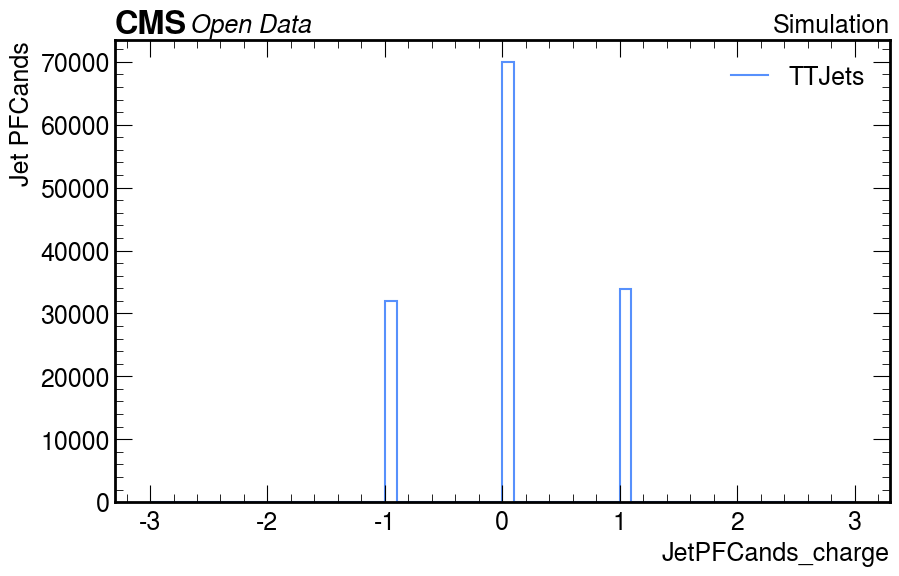

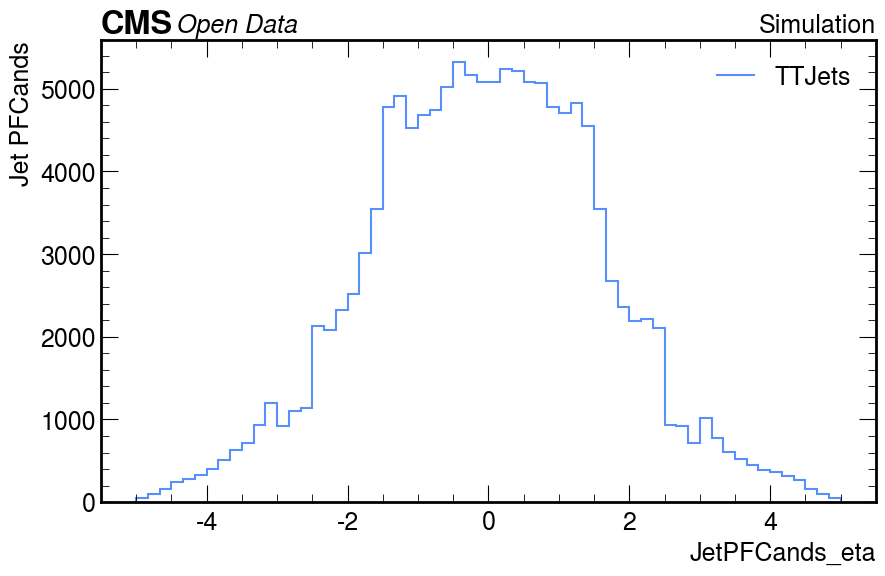

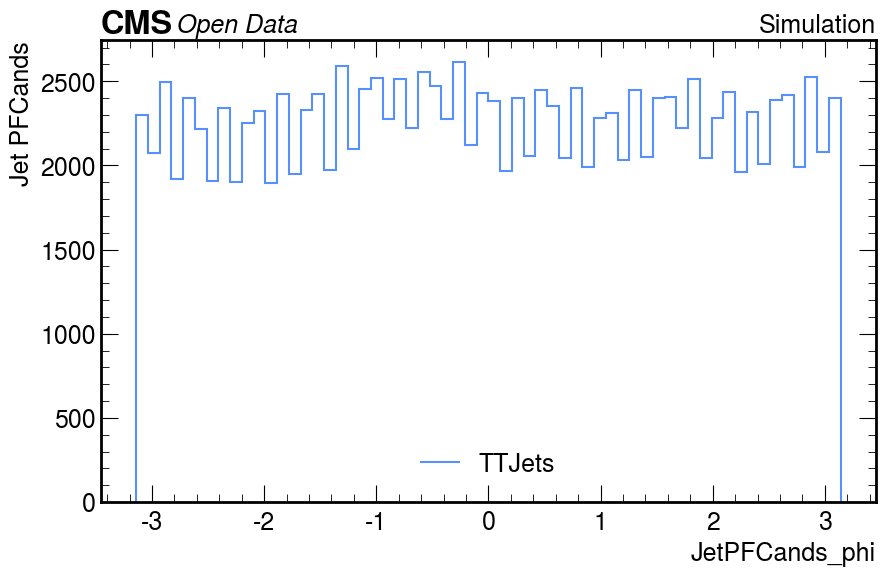

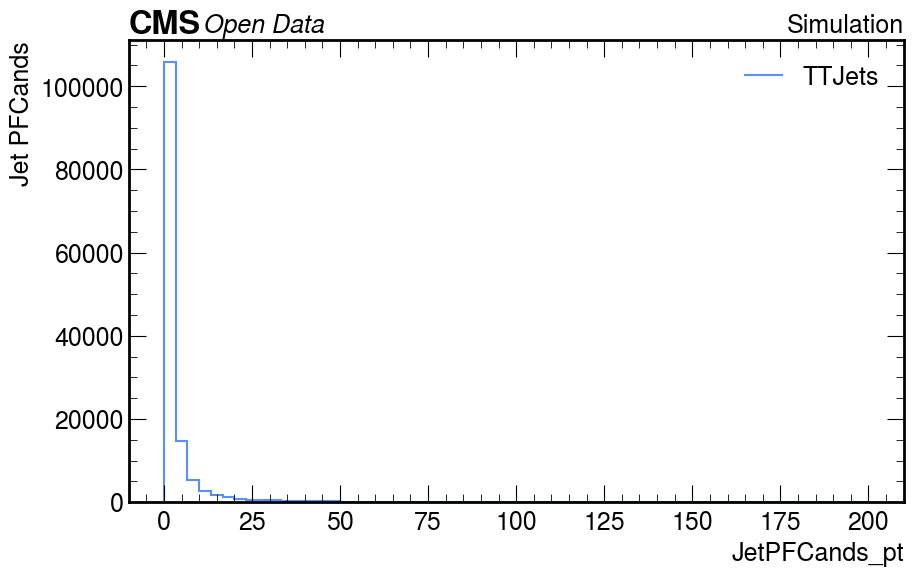

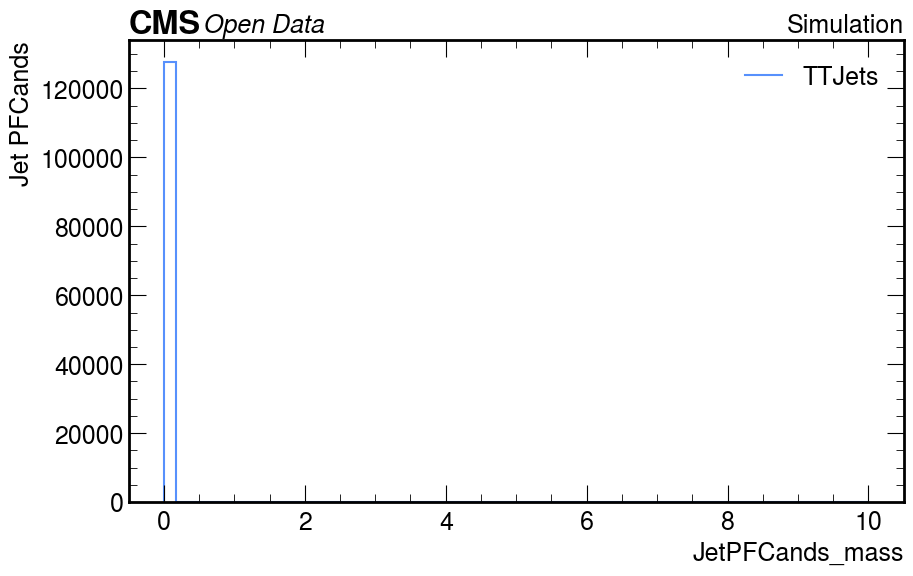

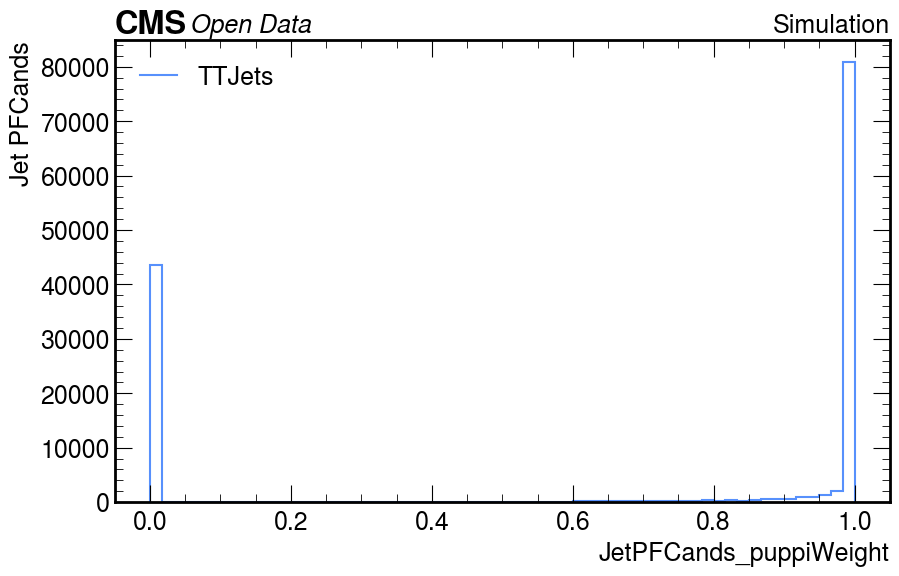

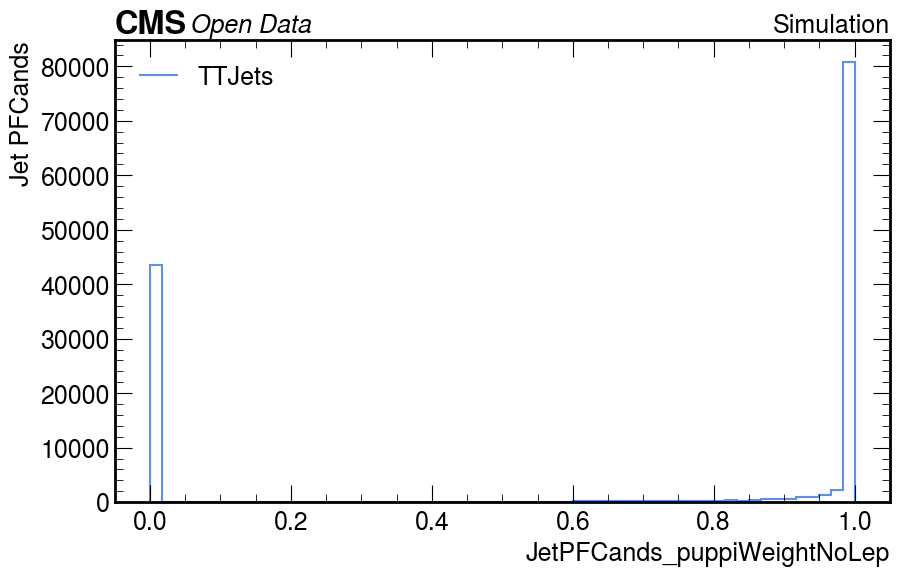

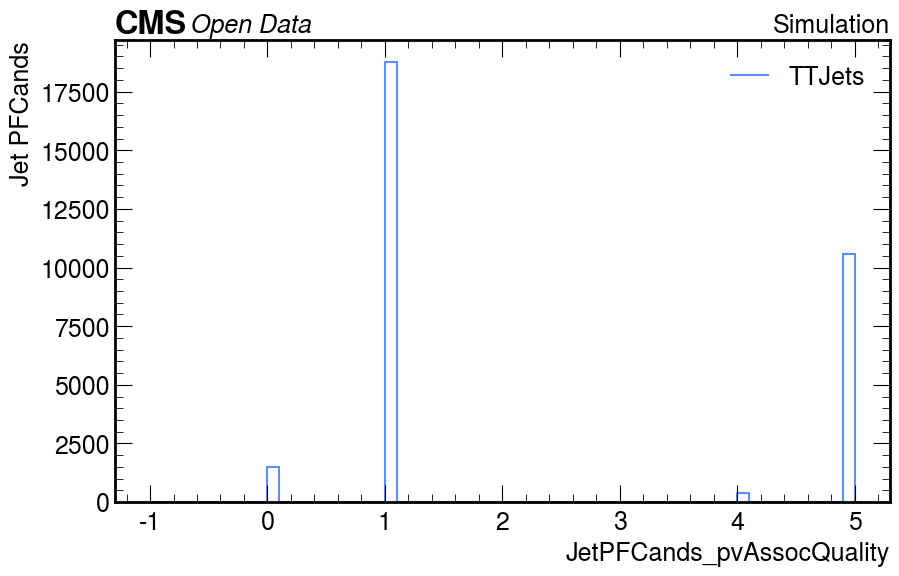

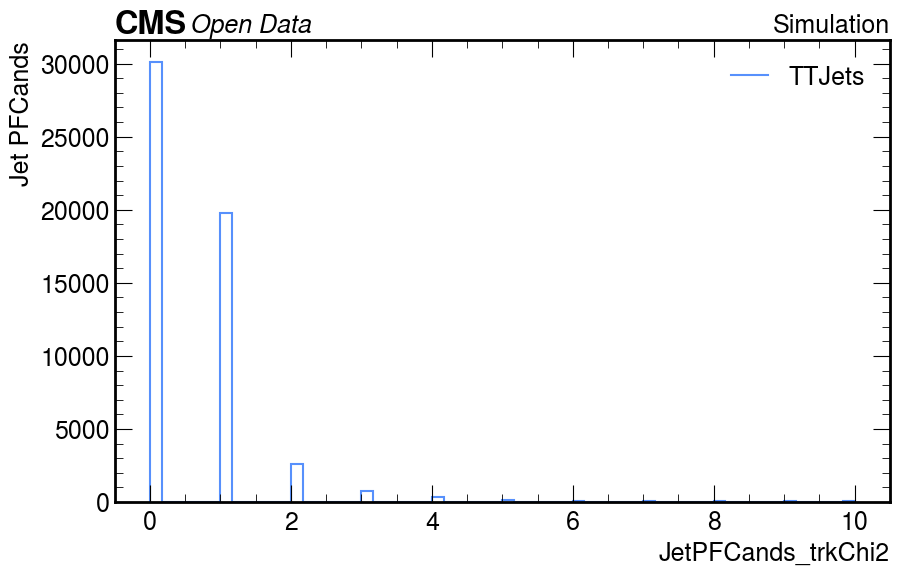

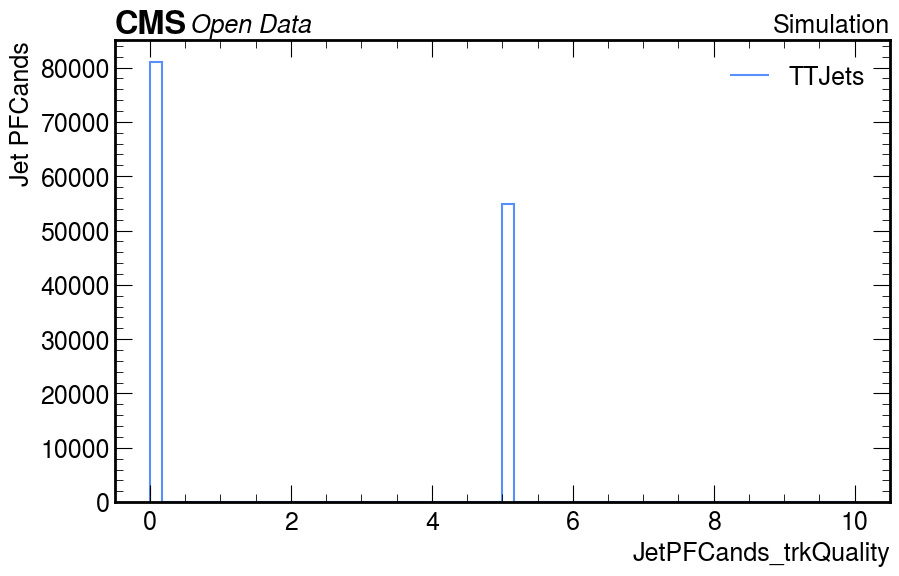

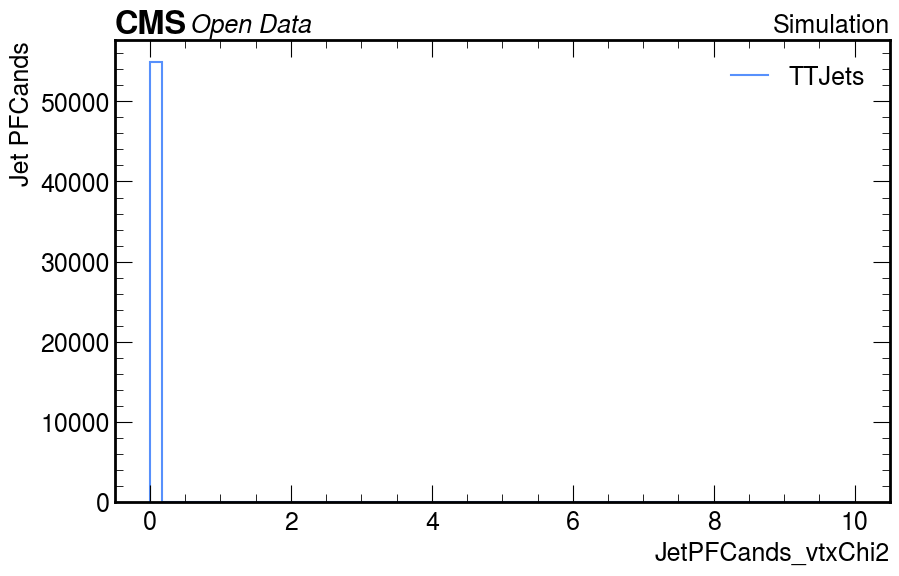

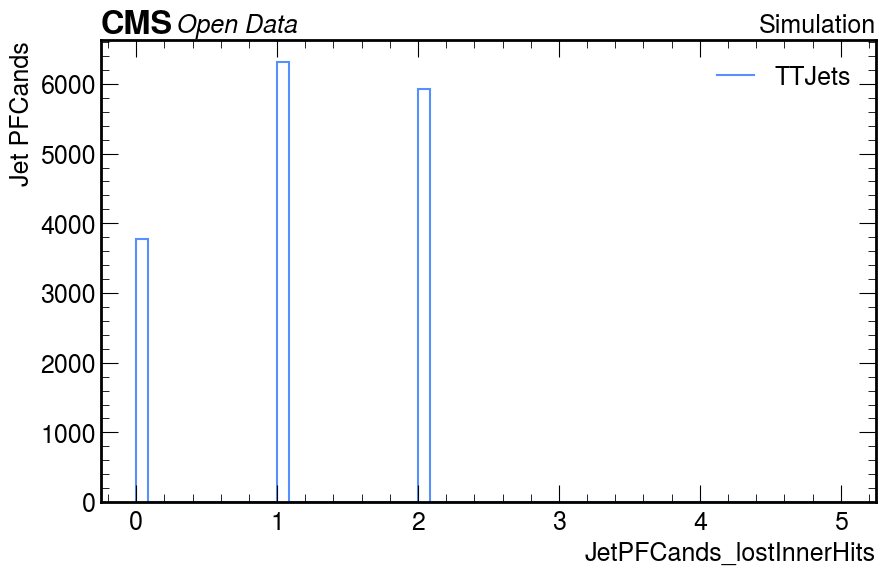

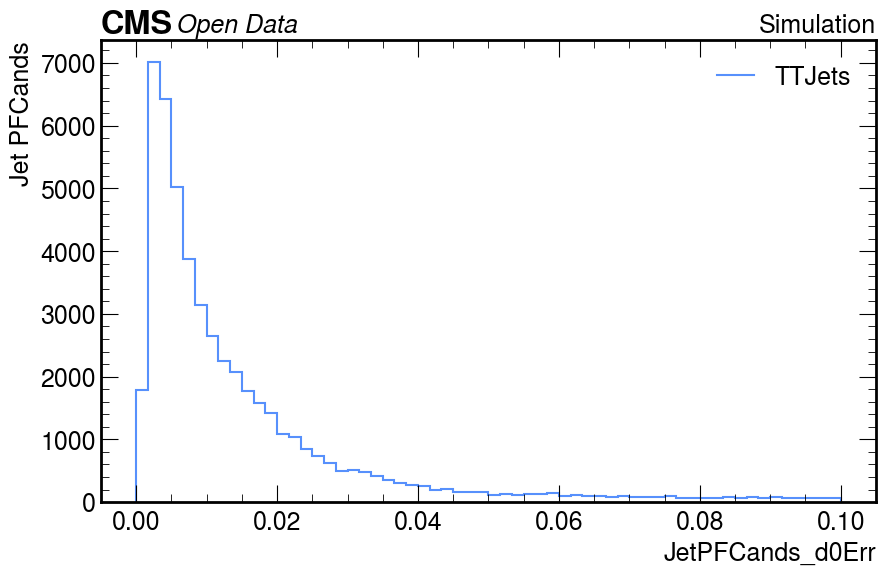

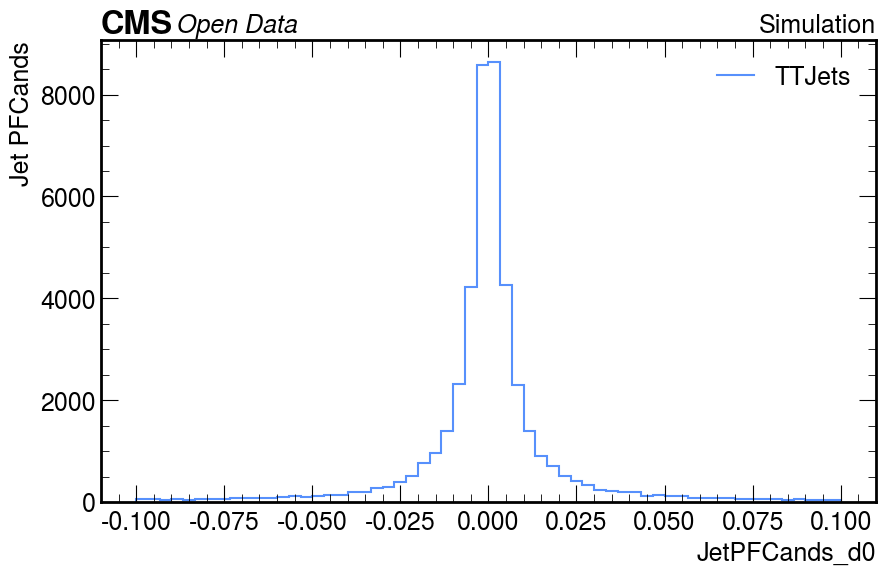

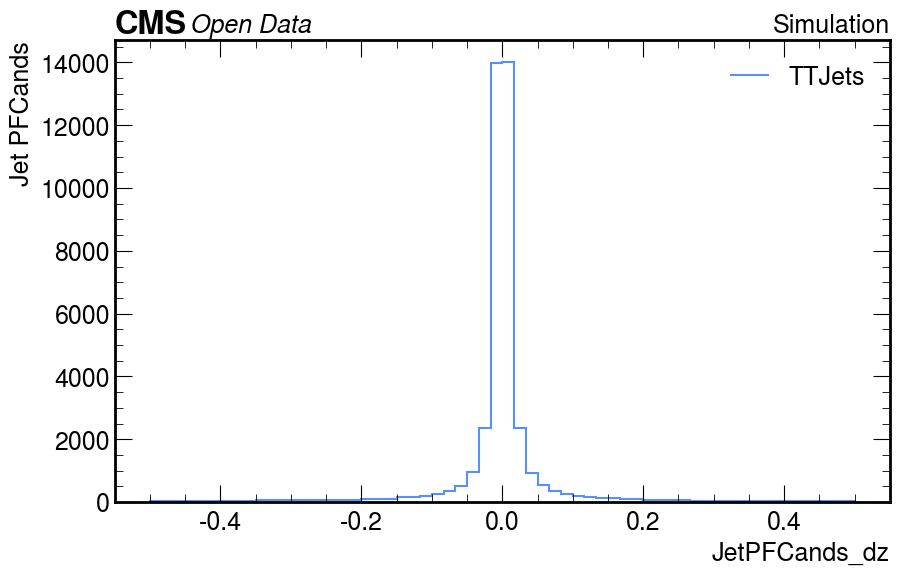

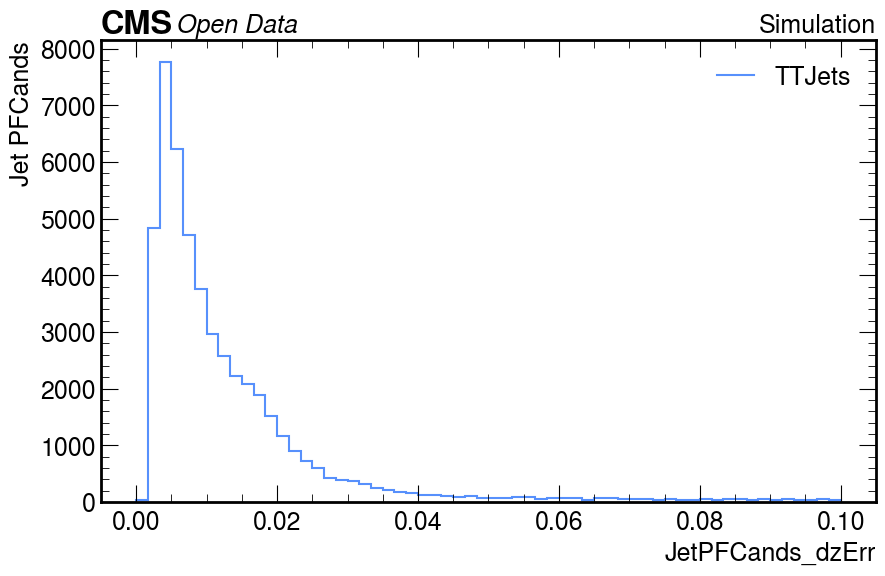

In [41]:
JetPFCands = btvNanoEvents.arrays(["JetPFCands_charge", "JetPFCands_eta", "JetPFCands_phi", "JetPFCands_pt", "JetPFCands_mass", "JetPFCands_puppiWeight", "JetPFCands_puppiWeightNoLep", "JetPFCands_pvAssocQuality", "JetPFCands_trkChi2", "JetPFCands_trkQuality", "JetPFCands_vtxChi2", "JetPFCands_lostInnerHits", "JetPFCands_d0Err", "JetPFCands_d0", "JetPFCands_dz", "JetPFCands_dzErr"], library="ak")

JetPFCands_charge = ak.flatten(JetPFCands["JetPFCands_charge"])
JetPFCands_eta = ak.flatten(JetPFCands["JetPFCands_eta"])
JetPFCands_phi = ak.flatten(JetPFCands["JetPFCands_phi"])
JetPFCands_pt = ak.flatten(JetPFCands["JetPFCands_pt"])
JetPFCands_mass = ak.flatten(JetPFCands["JetPFCands_mass"])
JetPFCands_puppiWeight = ak.flatten(JetPFCands["JetPFCands_puppiWeight"])
JetPFCands_puppiWeightNoLep = ak.flatten(JetPFCands["JetPFCands_puppiWeightNoLep"])
JetPFCands_pvAssocQuality = ak.flatten(JetPFCands["JetPFCands_pvAssocQuality"])
JetPFCands_trkChi2 = ak.flatten(JetPFCands["JetPFCands_trkChi2"])
JetPFCands_trkQuality = ak.flatten(JetPFCands["JetPFCands_trkQuality"])
JetPFCands_vtxChi2 = ak.flatten(JetPFCands["JetPFCands_vtxChi2"])
JetPFCands_lostInnerHits = ak.flatten(JetPFCands["JetPFCands_lostInnerHits"])
JetPFCands_d0Err = ak.flatten(JetPFCands["JetPFCands_d0Err"])
JetPFCands_d0 = ak.flatten(JetPFCands["JetPFCands_d0"])
JetPFCands_dz = ak.flatten(JetPFCands["JetPFCands_dz"])
JetPFCands_dzErr = ak.flatten(JetPFCands["JetPFCands_dzErr"])

make_hist(JetPFCands_charge, bins=60, range=(-3,3), xlabel=r"JetPFCands_charge", ylabel="Jet PFCands", title="Simulation", label="TTJets", fname="TTToSemiLeptonic/JetPFCands_charge.png", logy=False)
make_hist(JetPFCands_eta, bins=60, range=(-5,5), xlabel=r"JetPFCands_eta", ylabel="Jet PFCands", title="Simulation", label="TTJets", fname="TTToSemiLeptonic/JetPFCands_eta.png", logy=False)
make_hist(JetPFCands_phi, bins=60, range=(-np.pi,np.pi), xlabel=r"JetPFCands_phi", ylabel="Jet PFCands", title="Simulation", label="TTJets", fname="TTToSemiLeptonic/JetPFCands_phi.png", logy=False)
make_hist(JetPFCands_pt, bins=60, range=(0,200), xlabel=r"JetPFCands_pt", ylabel="Jet PFCands", title="Simulation", label="TTJets", fname="TTToSemiLeptonic/JetPFCands_pt.png", logy=False)
make_hist(JetPFCands_mass, bins=60, range=(0,10), xlabel=r"JetPFCands_mass", ylabel="Jet PFCands", title="Simulation", label="TTJets", fname="TTToSemiLeptonic/JetPFCands_mass.png", logy=False)
make_hist(JetPFCands_puppiWeight, bins=60, range=(0,1), xlabel=r"JetPFCands_puppiWeight", ylabel="Jet PFCands", title="Simulation", label="TTJets", fname="TTToSemiLeptonic/JetPFCands_puppiWeight.png", logy=False)
make_hist(JetPFCands_puppiWeightNoLep, bins=60, range=(0,1), xlabel=r"JetPFCands_puppiWeightNoLep", ylabel="Jet PFCands", title="Simulation", label="TTJets", fname="TTToSemiLeptonic/JetPFCands_puppiWeightNoLep.png", logy=False)
make_hist(JetPFCands_pvAssocQuality, bins=60, range=(-1,5), xlabel=r"JetPFCands_pvAssocQuality", ylabel="Jet PFCands", title="Simulation", label="TTJets", fname="TTToSemiLeptonic/JetPFCands_pvAssocQuality.png", logy=False)
make_hist(JetPFCands_trkChi2, bins=60, range=(0,10), xlabel=r"JetPFCands_trkChi2", ylabel="Jet PFCands", title="Simulation", label="TTJets", fname="TTToSemiLeptonic/JetPFCands_trkChi2.png", logy=False)
make_hist(JetPFCands_trkQuality, bins=60, range=(0,10), xlabel=r"JetPFCands_trkQuality", ylabel="Jet PFCands", title="Simulation", label="TTJets", fname="TTToSemiLeptonic/JetPFCands_trkQuality.png", logy=False)
make_hist(JetPFCands_vtxChi2, bins=60, range=(0,10), xlabel=r"JetPFCands_vtxChi2", ylabel="Jet PFCands", title="Simulation", label="TTJets", fname="TTToSemiLeptonic/JetPFCands_vtxChi2.png", logy=False)
make_hist(JetPFCands_lostInnerHits, bins=60, range=(0,5), xlabel=r"JetPFCands_lostInnerHits", ylabel="Jet PFCands", title="Simulation", label="TTJets", fname="TTToSemiLeptonic/JetPFCands_lostInnerHits.png", logy=False)
make_hist(JetPFCands_d0Err, bins=60, range=(0,0.1), xlabel=r"JetPFCands_d0Err", ylabel="Jet PFCands", title="Simulation", label="TTJets", fname="TTToSemiLeptonic/JetPFCands_d0Err.png", logy=False)
make_hist(JetPFCands_d0, bins=60, range=(-0.1,0.1), xlabel=r"JetPFCands_d0", ylabel="Jet PFCands", title="Simulation", label="TTJets", fname="TTToSemiLeptonic/JetPFCands_d0.png", logy=False)
make_hist(JetPFCands_dz, bins=60, range=(-0.5,0.5), xlabel=r"JetPFCands_dz", ylabel="Jet PFCands", title="Simulation", label="TTJets", fname="TTToSemiLeptonic/JetPFCands_dz.png", logy=False)
make_hist(JetPFCands_dzErr, bins=60, range=(0,0.1), xlabel=r"JetPFCands_dzErr", ylabel="Jet PFCands", title="Simulation", label="TTJets", fname="TTToSemiLeptonic/JetPFCands_dzErr.png", logy=False)

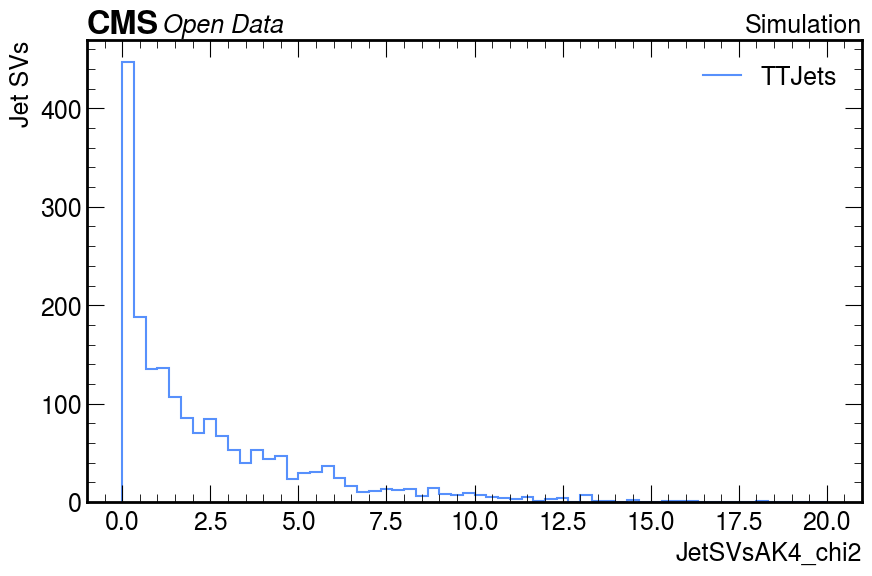

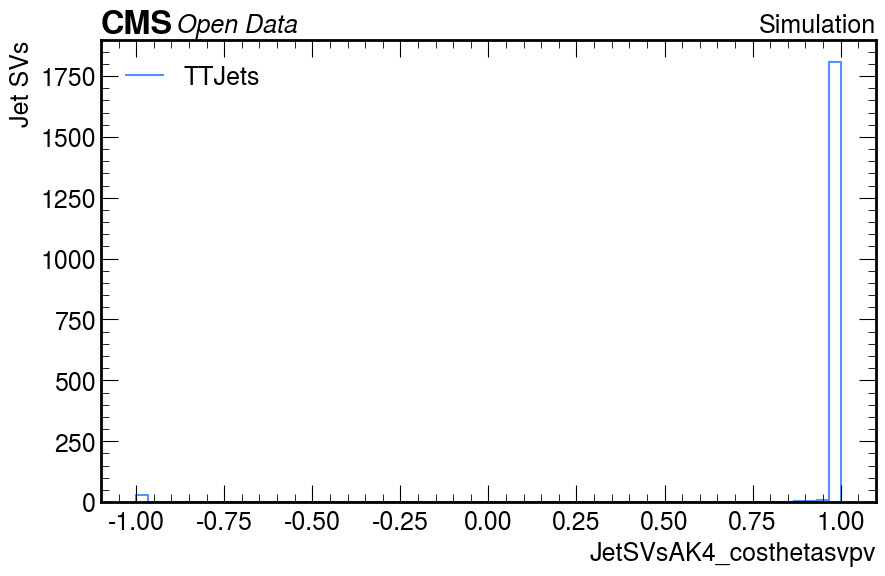

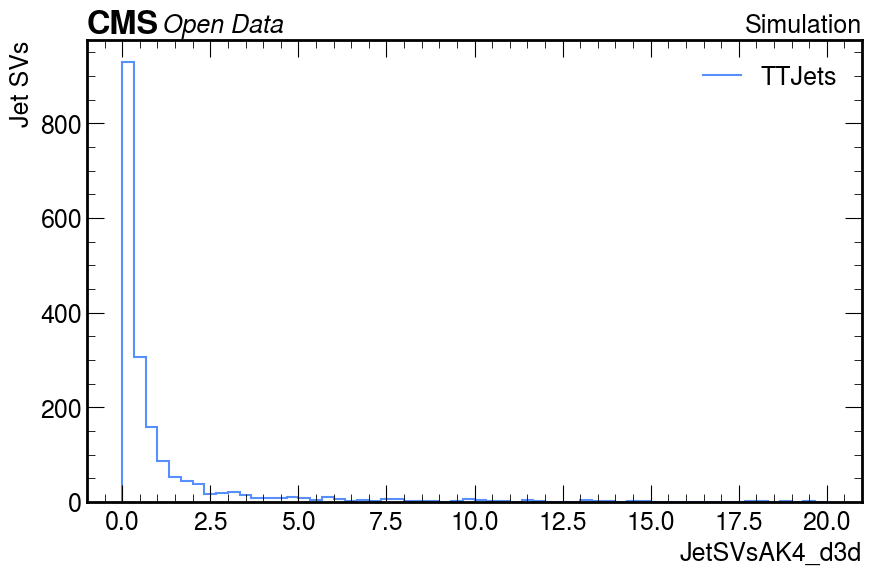

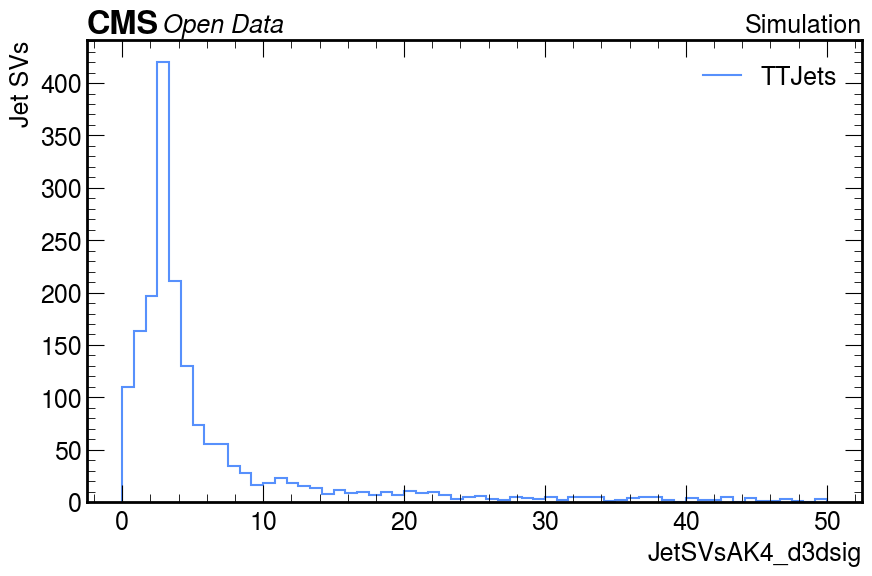

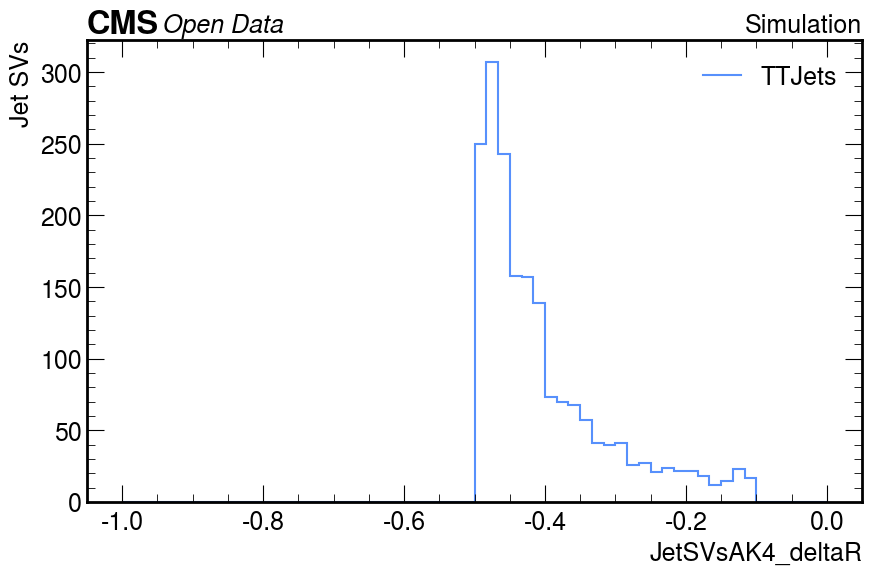

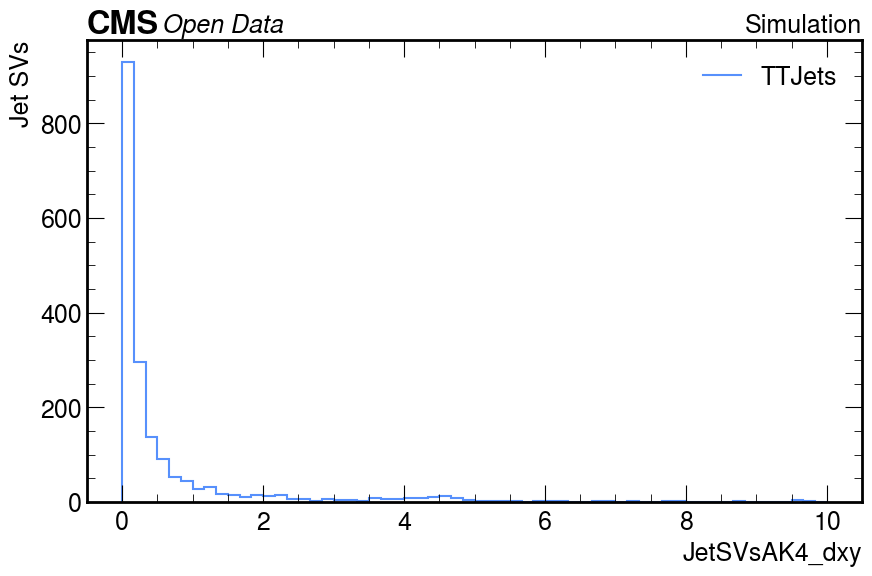

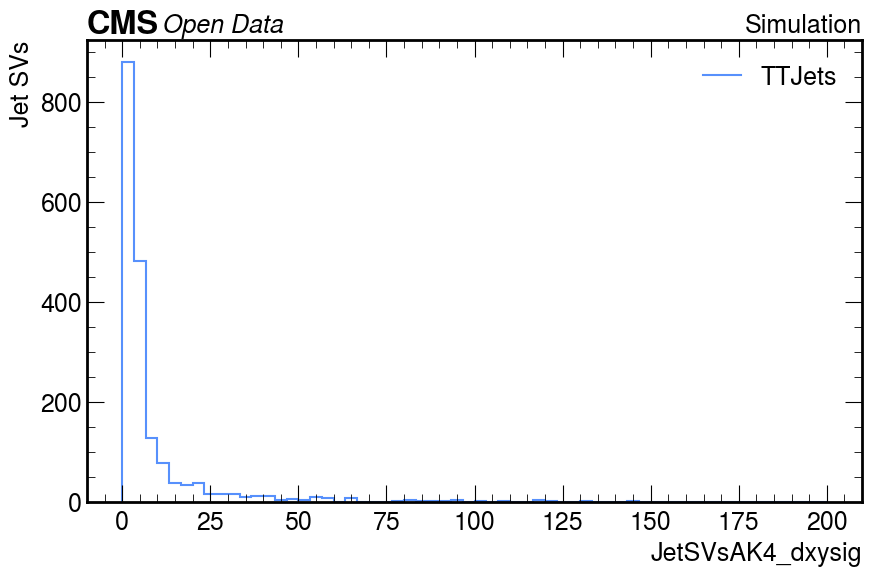

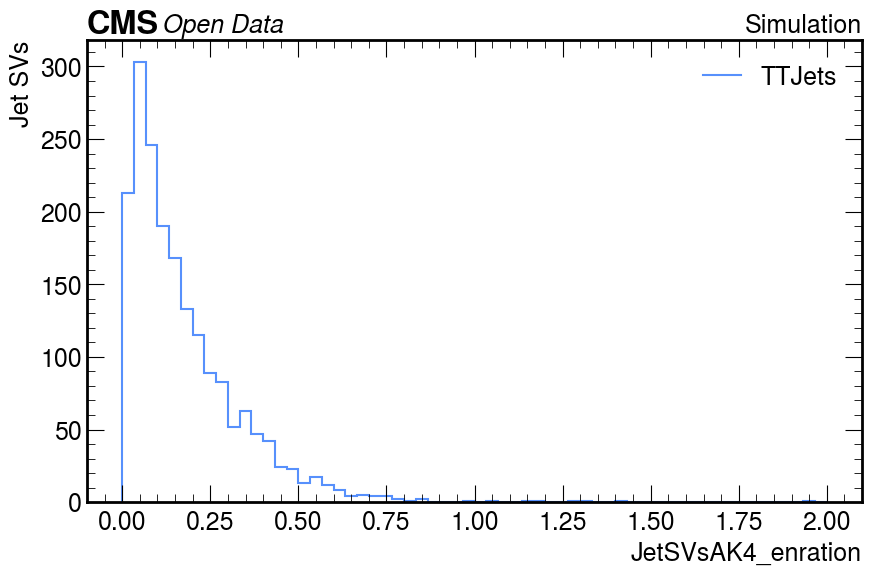

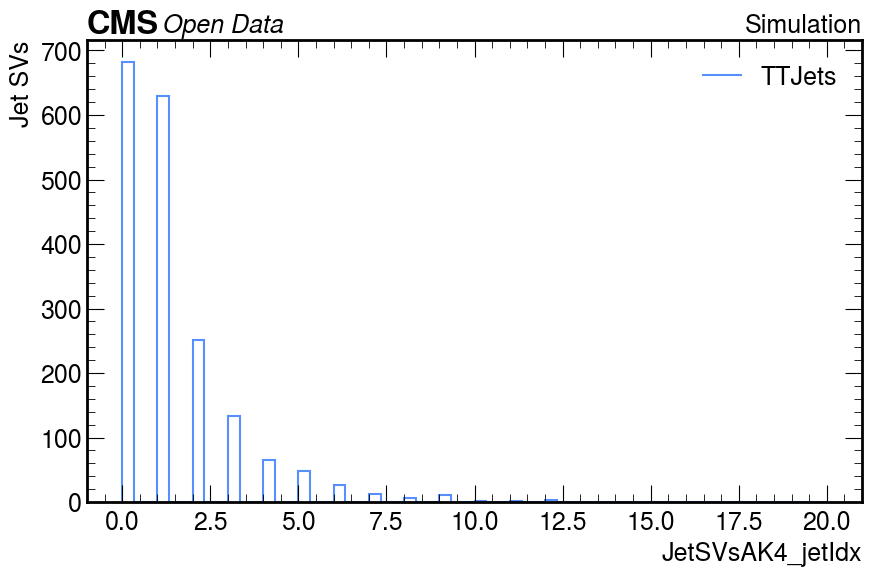

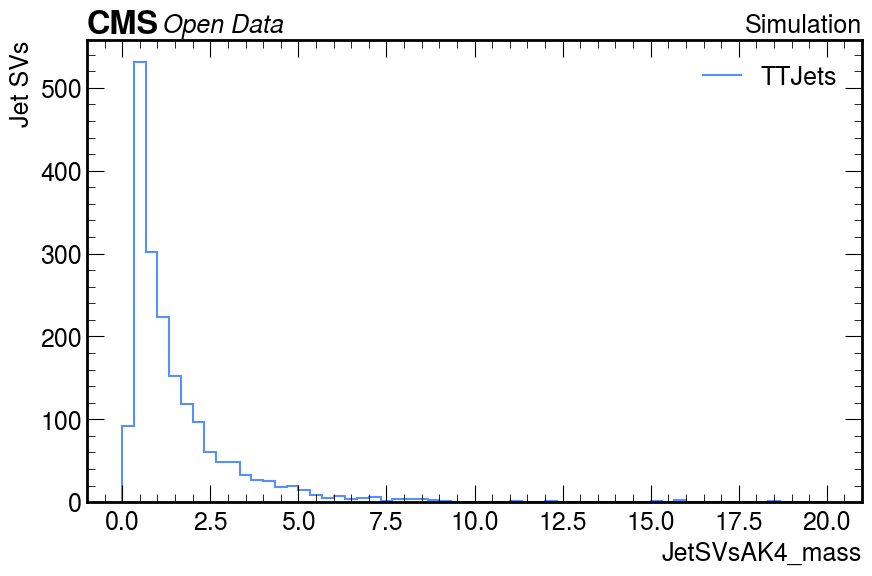

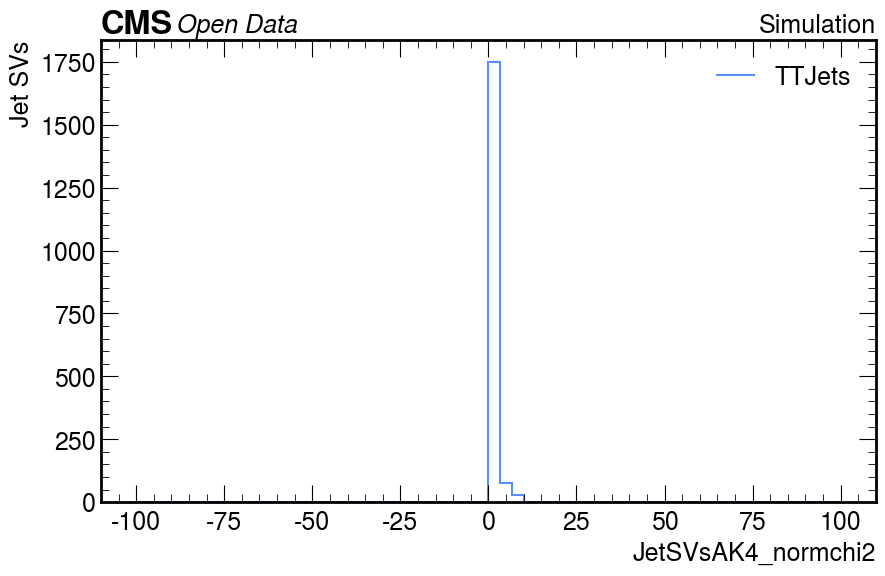

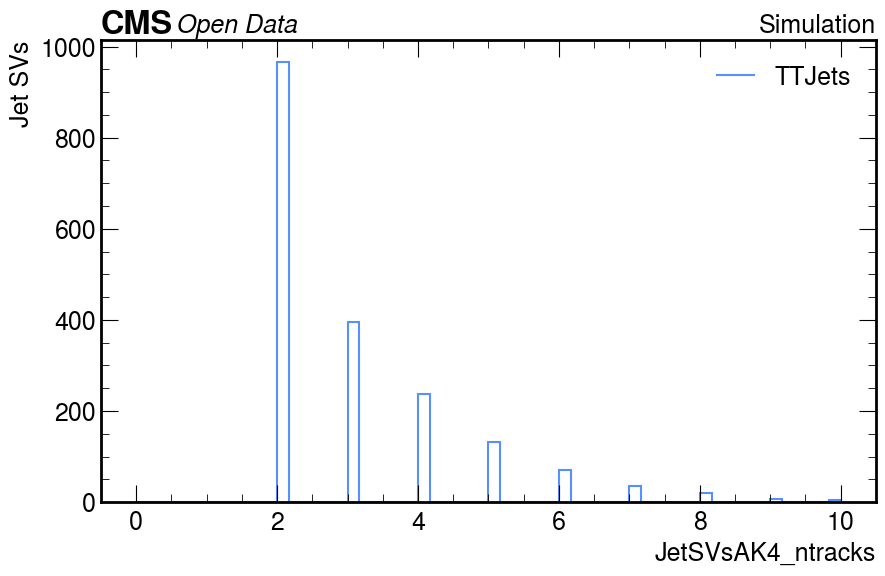

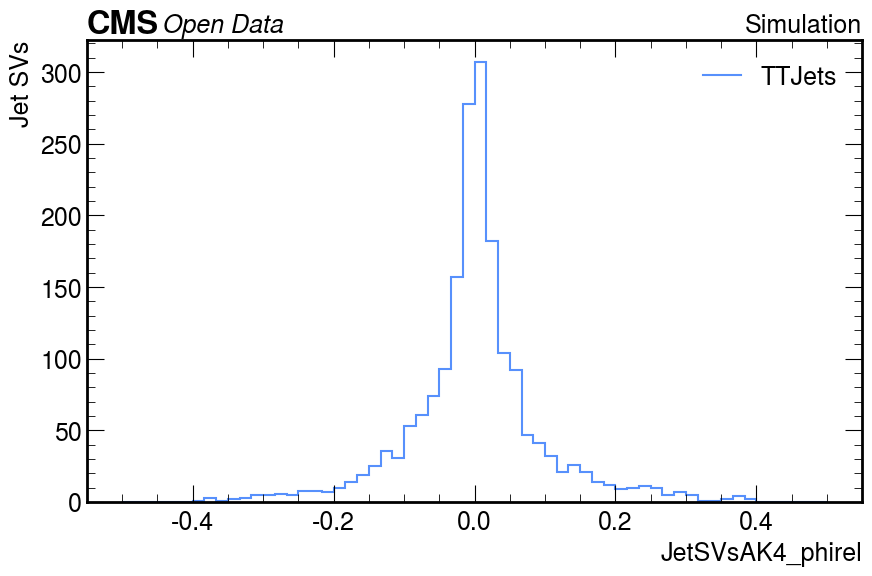

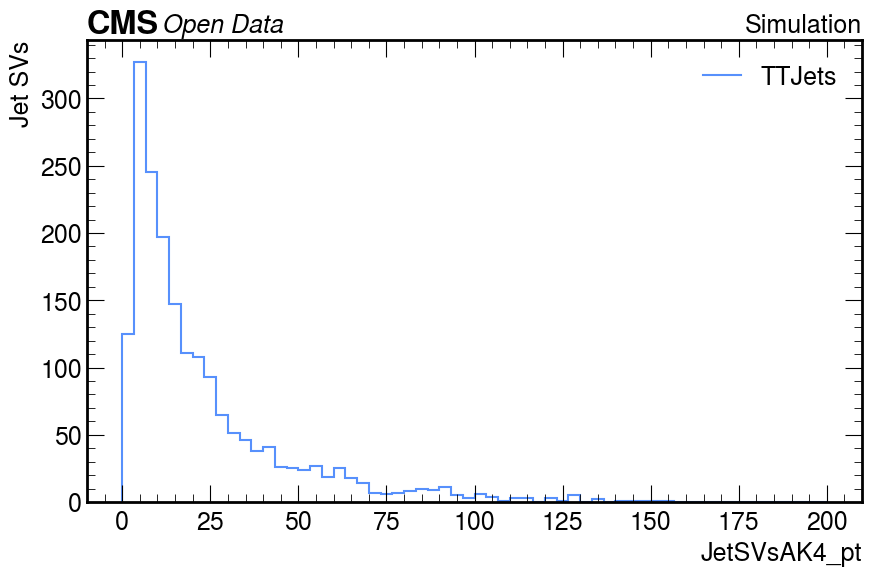

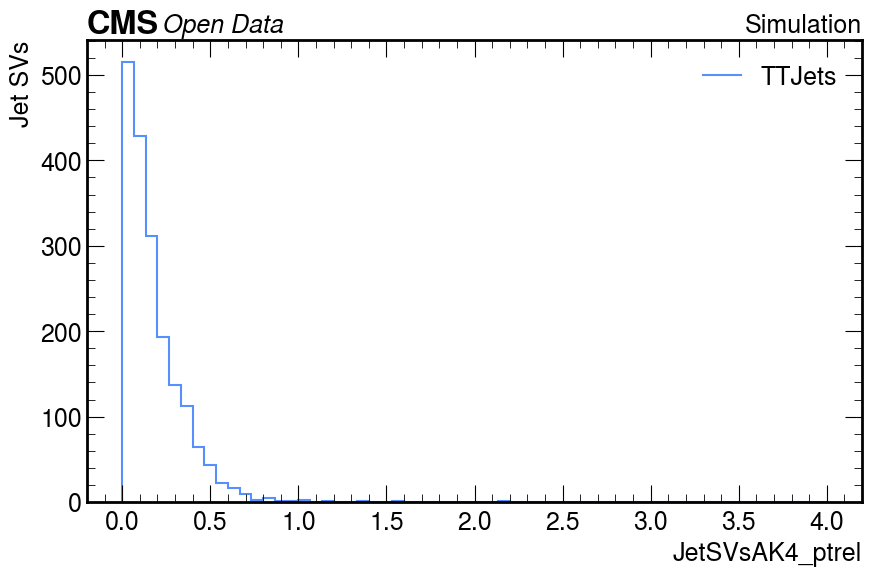

In [42]:
JetSVsAK4 = btvNanoEvents.arrays(["JetSVsAK4_chi2","JetSVsAK4_costhetasvpv", "JetSVsAK4_d3d", "JetSVsAK4_d3dsig", "JetSVsAK4_deltaR", "JetSVsAK4_dxy", "JetSVsAK4_dxysig", "JetSVsAK4_enration", "JetSVsAK4_jetIdx", "JetSVsAK4_mass", "JetSVsAK4_normchi2", "JetSVsAK4_ntracks", "JetSVsAK4_phirel", "JetSVsAK4_pt", "JetSVsAK4_ptrel"], library="ak")

JetSVsAK4_chi2 = ak.flatten(JetSVsAK4["JetSVsAK4_chi2"])
JetSVsAK4_costhetasvpv = ak.flatten(JetSVsAK4["JetSVsAK4_costhetasvpv"])
JetSVsAK4_d3d = ak.flatten(JetSVsAK4["JetSVsAK4_d3d"])
JetSVsAK4_d3dsig = ak.flatten(JetSVsAK4["JetSVsAK4_d3dsig"])
JetSVsAK4_deltaR = ak.flatten(JetSVsAK4["JetSVsAK4_deltaR"])
JetSVsAK4_dxy = ak.flatten(JetSVsAK4["JetSVsAK4_dxy"])
JetSVsAK4_dxysig = ak.flatten(JetSVsAK4["JetSVsAK4_dxysig"])
JetSVsAK4_enration = ak.flatten(JetSVsAK4["JetSVsAK4_enration"])
JetSVsAK4_jetIdx = ak.flatten(JetSVsAK4["JetSVsAK4_jetIdx"])
JetSVsAK4_mass = ak.flatten(JetSVsAK4["JetSVsAK4_mass"])
JetSVsAK4_normchi2 = ak.flatten(JetSVsAK4["JetSVsAK4_normchi2"])
JetSVsAK4_ntracks = ak.flatten(JetSVsAK4["JetSVsAK4_ntracks"])
JetSVsAK4_phirel = ak.flatten(JetSVsAK4["JetSVsAK4_phirel"])
JetSVsAK4_pt = ak.flatten(JetSVsAK4["JetSVsAK4_pt"])
JetSVsAK4_ptrel = ak.flatten(JetSVsAK4["JetSVsAK4_ptrel"])

make_hist(JetSVsAK4_chi2, bins=60, range=(0,20), xlabel=r"JetSVsAK4_chi2", ylabel="Jet SVs", title="Simulation", label="TTJets", fname="TTToSemiLeptonic/JetSVsAK4_chi2.png", logy=False)
make_hist(JetSVsAK4_costhetasvpv, bins=60, range=(-1,1), xlabel=r"JetSVsAK4_costhetasvpv", ylabel="Jet SVs", title="Simulation", label="TTJets", fname="TTToSemiLeptonic/JetSVsAK4_costhetasvpv.png", logy=False)
make_hist(JetSVsAK4_d3d, bins=60, range=(0,20), xlabel=r"JetSVsAK4_d3d", ylabel="Jet SVs", title="Simulation", label="TTJets", fname="TTToSemiLeptonic/JetSVsAK4_d3d.png", logy=False)
make_hist(JetSVsAK4_d3dsig, bins=60, range=(0,50), xlabel=r"JetSVsAK4_d3dsig", ylabel="Jet SVs", title="Simulation", label="TTJets", fname="TTToSemiLeptonic/JetSVsAK4_d3dsig.png", logy=False)
make_hist(JetSVsAK4_deltaR, bins=60, range=(-1,0), xlabel=r"JetSVsAK4_deltaR", ylabel="Jet SVs", title="Simulation", label="TTJets", fname="TTToSemiLeptonic/JetSVsAK4_deltaR.png", logy=False)
make_hist(JetSVsAK4_dxy, bins=60, range=(0,10), xlabel=r"JetSVsAK4_dxy", ylabel="Jet SVs", title="Simulation", label="TTJets", fname="TTToSemiLeptonic/JetSVsAK4_dxy.png", logy=False)
make_hist(JetSVsAK4_dxysig, bins=60, range=(0,200), xlabel=r"JetSVsAK4_dxysig", ylabel="Jet SVs", title="Simulation", label="TTJets", fname="TTToSemiLeptonic/JetSVsAK4_dxysig.png", logy=False)
make_hist(JetSVsAK4_enration, bins=60, range=(0,2), xlabel=r"JetSVsAK4_enration", ylabel="Jet SVs", title="Simulation", label="TTJets", fname="TTToSemiLeptonic/JetSVsAK4_enration.png", logy=False)
make_hist(JetSVsAK4_jetIdx, bins=60, range=(0,20), xlabel=r"JetSVsAK4_jetIdx", ylabel="Jet SVs", title="Simulation", label="TTJets", fname="TTToSemiLeptonic/JetSVsAK4_jetIdx.png", logy=False)
make_hist(JetSVsAK4_mass, bins=60, range=(0,20), xlabel=r"JetSVsAK4_mass", ylabel="Jet SVs", title="Simulation", label="TTJets", fname="TTToSemiLeptonic/JetSVsAK4_mass.png", logy=False)
make_hist(JetSVsAK4_normchi2, bins=60, range=(-100,100), xlabel=r"JetSVsAK4_normchi2", ylabel="Jet SVs", title="Simulation", label="TTJets", fname="TTToSemiLeptonic/JetSVsAK4_normchi2.png", logy=False)
make_hist(JetSVsAK4_ntracks, bins=60, range=(0,10), xlabel=r"JetSVsAK4_ntracks", ylabel="Jet SVs", title="Simulation", label="TTJets", fname="TTToSemiLeptonic/JetSVsAK4_ntracks.png", logy=False)
make_hist(JetSVsAK4_phirel, bins=60, range=(-0.5,0.5), xlabel=r"JetSVsAK4_phirel", ylabel="Jet SVs", title="Simulation", label="TTJets", fname="TTToSemiLeptonic/JetSVsAK4_phirel.png", logy=False)
make_hist(JetSVsAK4_pt, bins=60, range=(0,200), xlabel=r"JetSVsAK4_pt", ylabel="Jet SVs", title="Simulation", label="TTJets", fname="TTToSemiLeptonic/JetSVsAK4_pt.png", logy=False)
make_hist(JetSVsAK4_ptrel, bins=60, range=(0,4), xlabel=r"JetSVsAK4_ptrel", ylabel="Jet SVs", title="Simulation", label="TTJets", fname="TTToSemiLeptonic/JetSVsAK4_ptrel.png", logy=False)

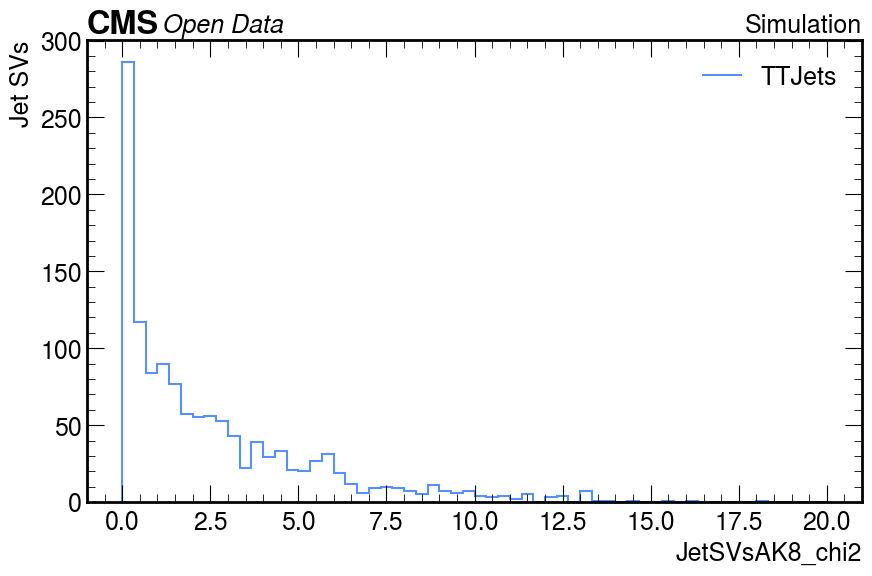

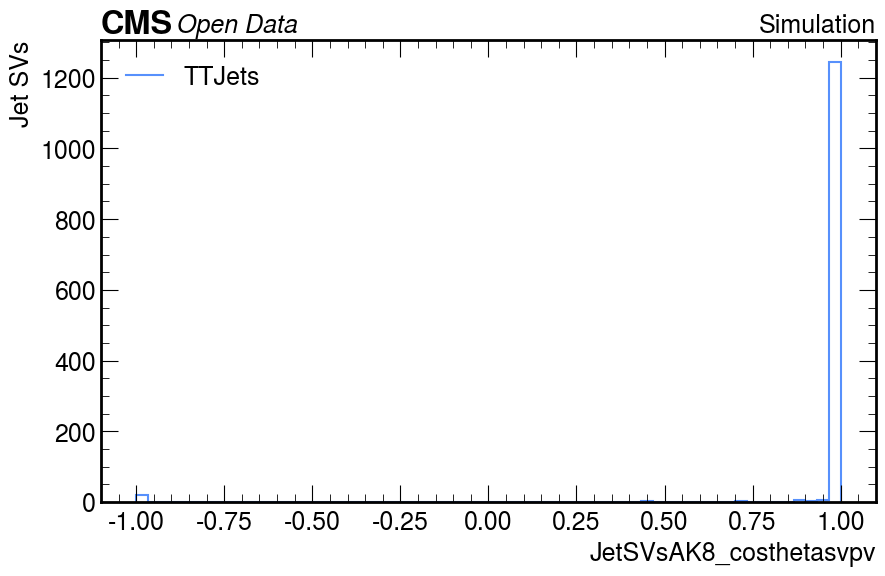

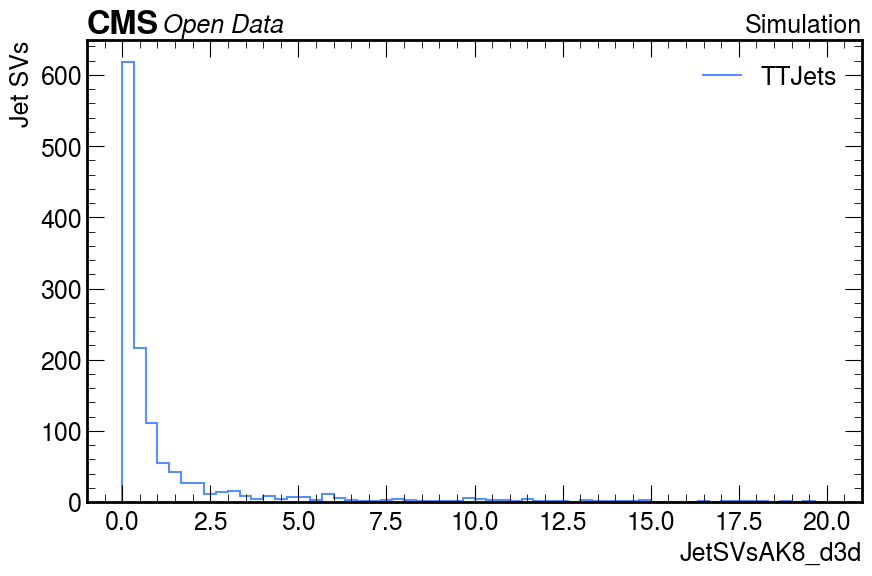

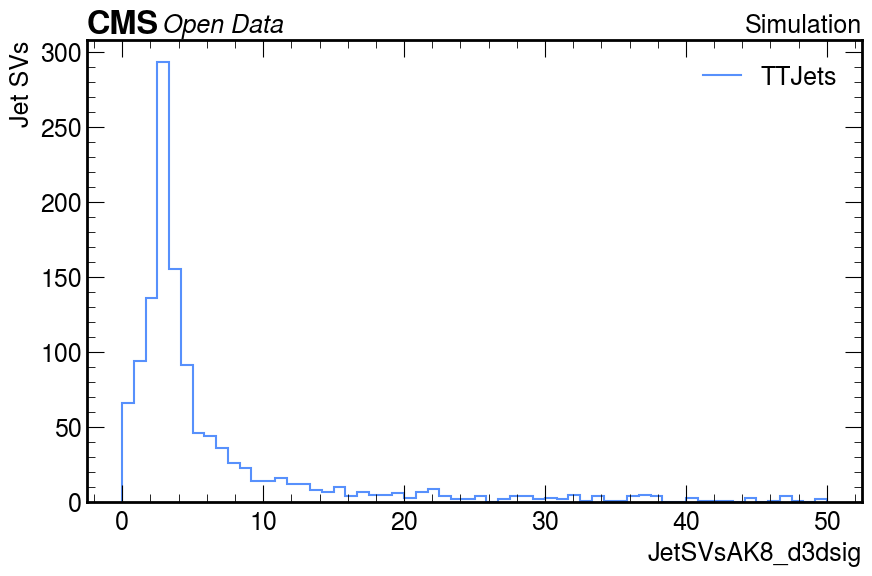

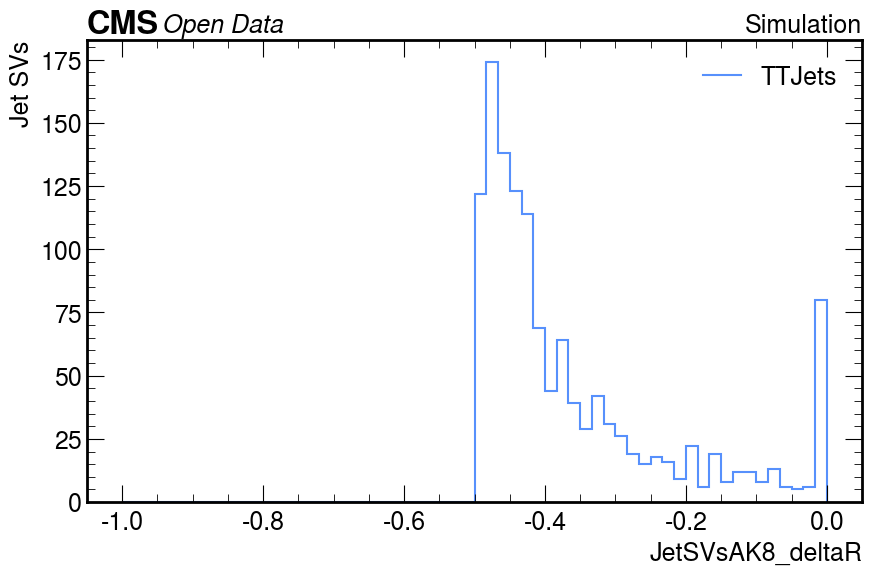

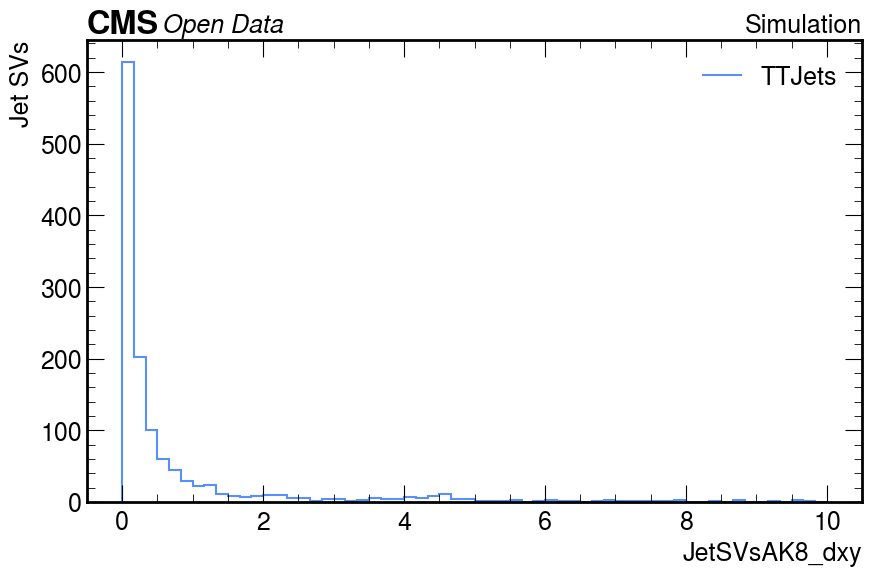

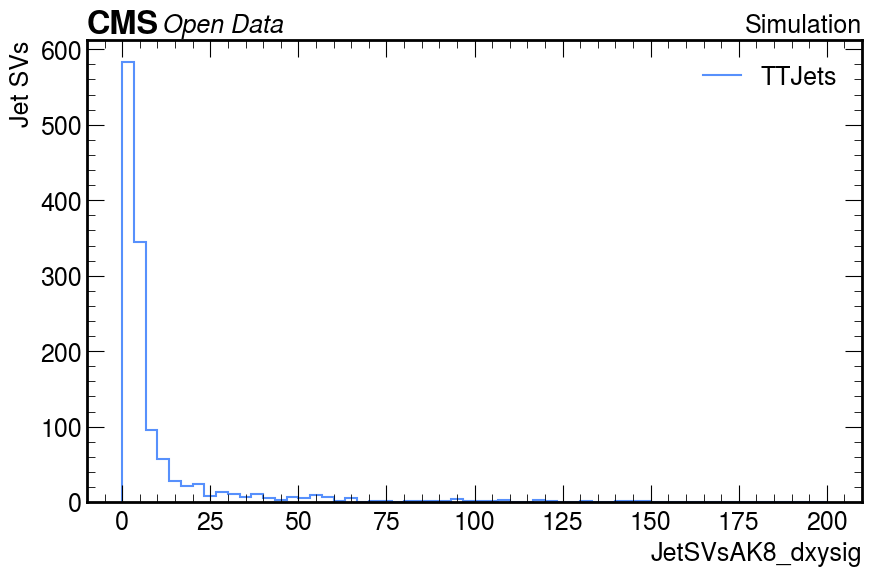

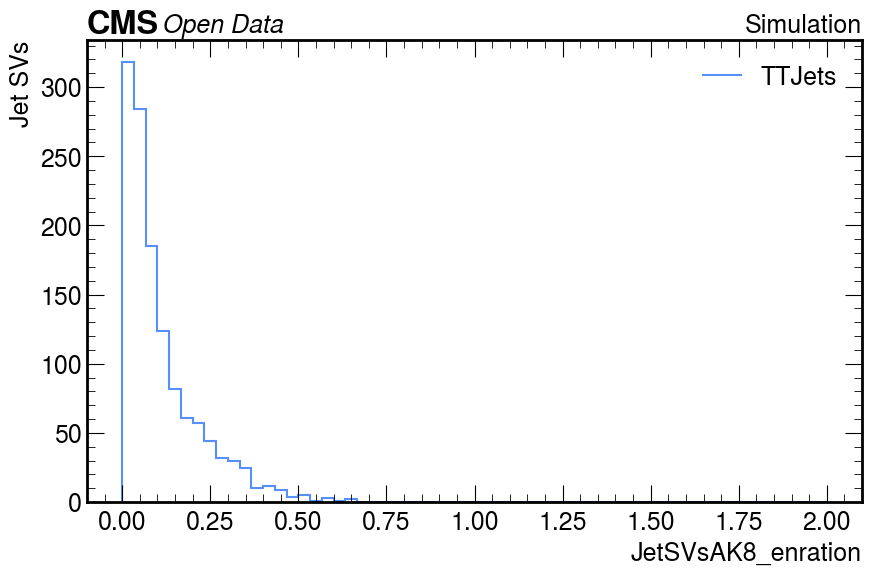

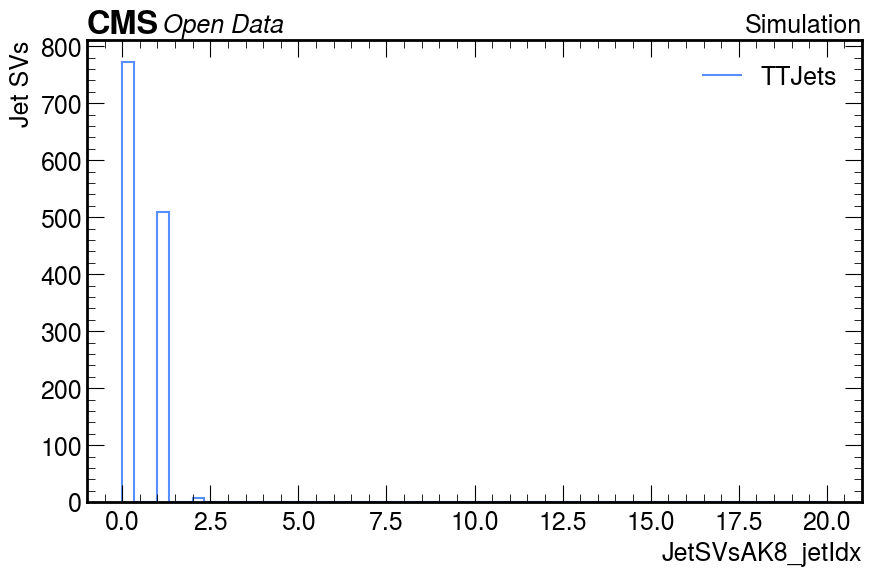

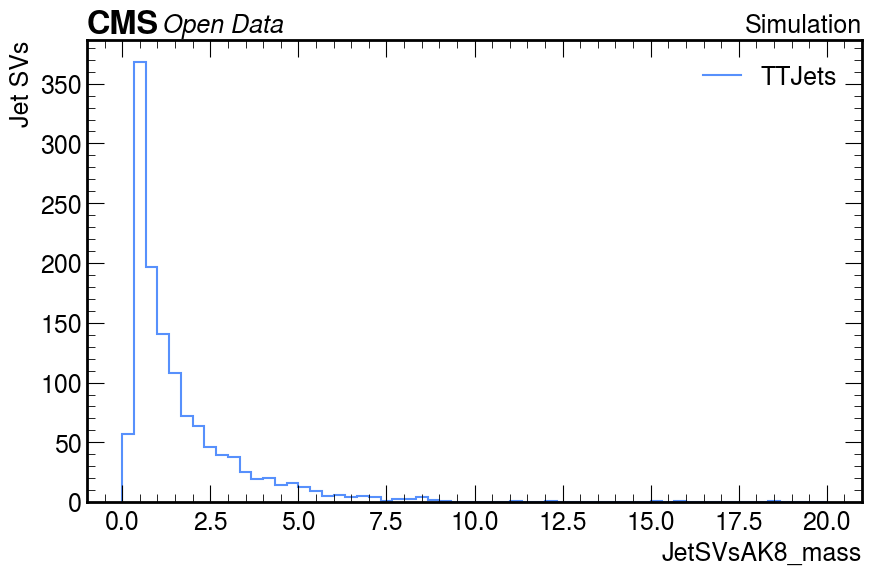

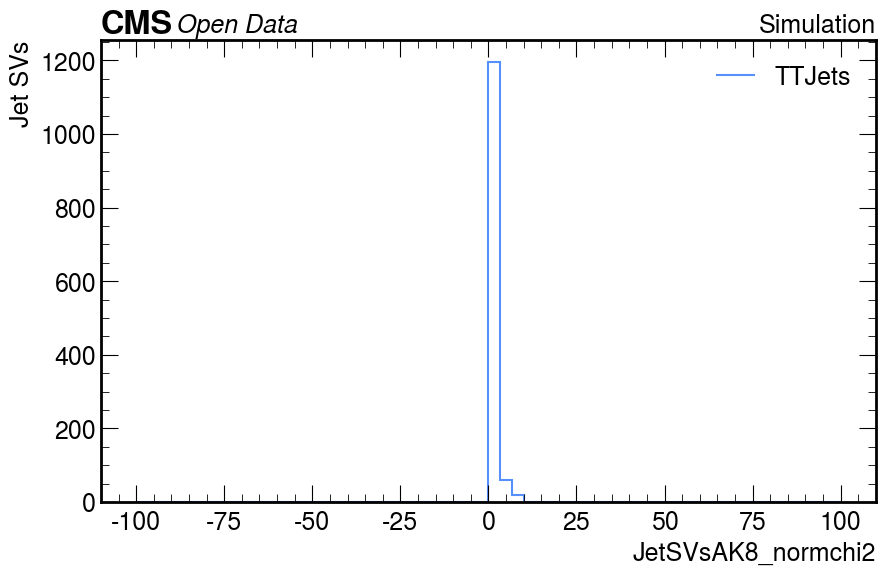

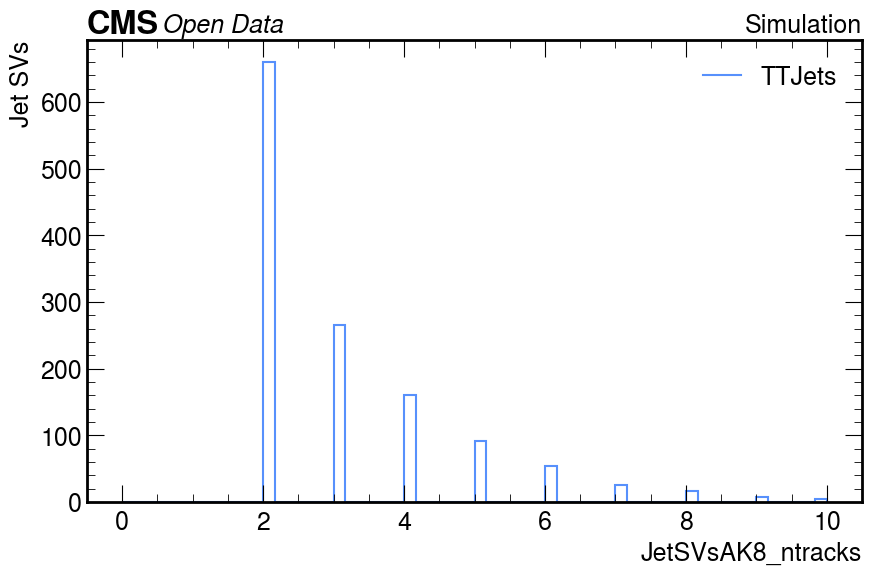

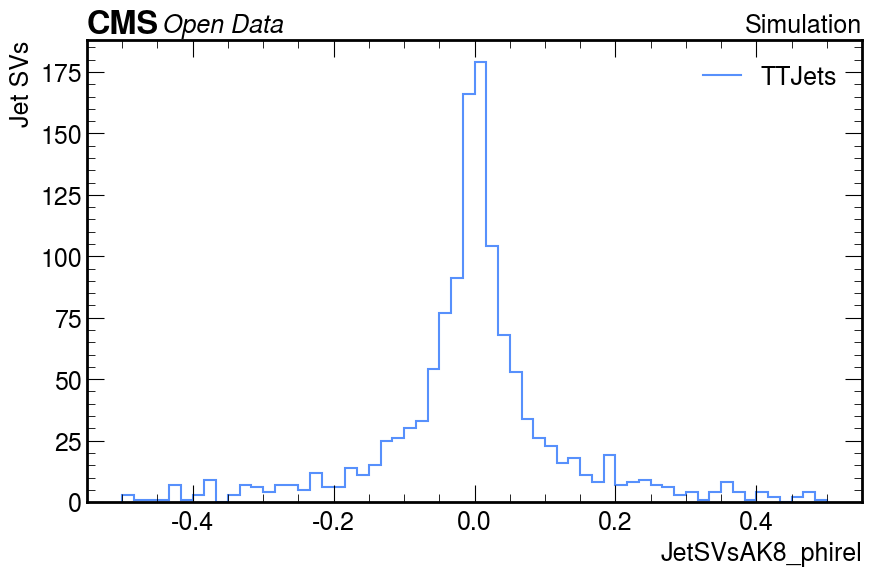

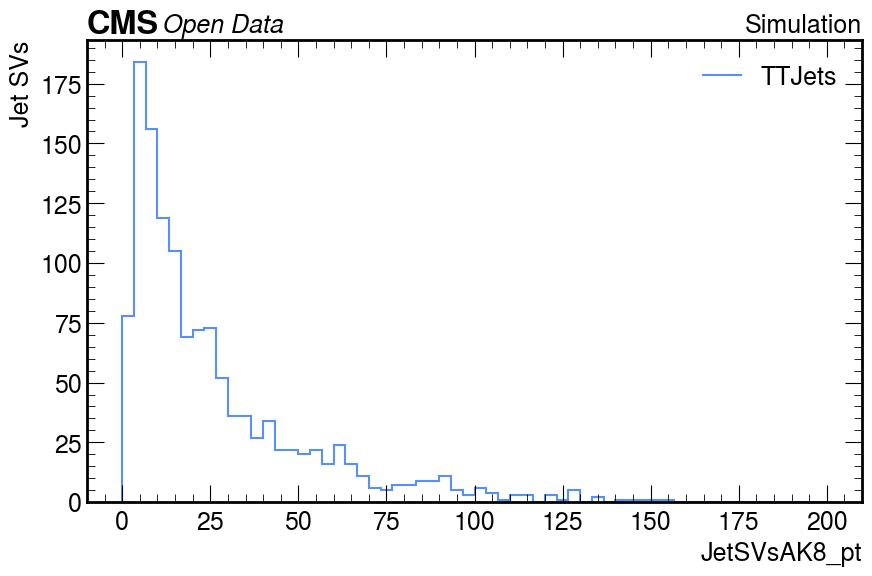

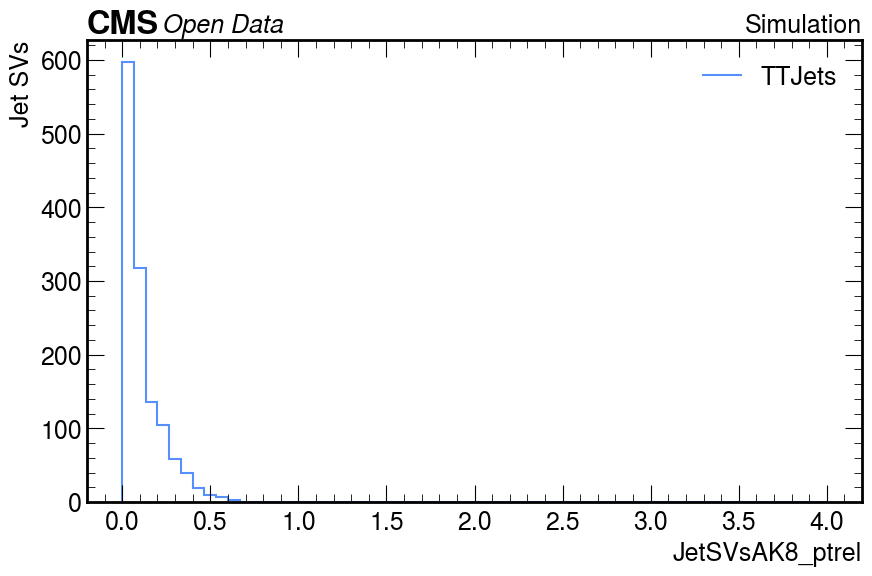

In [33]:
JetSVsAK8 = btvNanoEvents.arrays(["JetSVsAK8_chi2","JetSVsAK8_costhetasvpv", "JetSVsAK8_d3d", "JetSVsAK8_d3dsig", "JetSVsAK8_deltaR", "JetSVsAK8_dxy", "JetSVsAK8_dxysig", "JetSVsAK8_enration", "JetSVsAK8_jetIdx", "JetSVsAK8_mass", "JetSVsAK8_normchi2", "JetSVsAK8_ntracks", "JetSVsAK8_phirel", "JetSVsAK8_pt", "JetSVsAK8_ptrel"], library="ak")

JetSVsAK8_chi2 = ak.flatten(JetSVsAK8["JetSVsAK8_chi2"])
JetSVsAK8_costhetasvpv = ak.flatten(JetSVsAK8["JetSVsAK8_costhetasvpv"])
JetSVsAK8_d3d = ak.flatten(JetSVsAK8["JetSVsAK8_d3d"])
JetSVsAK8_d3dsig = ak.flatten(JetSVsAK8["JetSVsAK8_d3dsig"])
JetSVsAK8_deltaR = ak.flatten(JetSVsAK8["JetSVsAK8_deltaR"])
JetSVsAK8_dxy = ak.flatten(JetSVsAK8["JetSVsAK8_dxy"])
JetSVsAK8_dxysig = ak.flatten(JetSVsAK8["JetSVsAK8_dxysig"])
JetSVsAK8_enration = ak.flatten(JetSVsAK8["JetSVsAK8_enration"])
JetSVsAK8_jetIdx = ak.flatten(JetSVsAK8["JetSVsAK8_jetIdx"])
JetSVsAK8_mass = ak.flatten(JetSVsAK8["JetSVsAK8_mass"])
JetSVsAK8_normchi2 = ak.flatten(JetSVsAK8["JetSVsAK8_normchi2"])
JetSVsAK8_ntracks = ak.flatten(JetSVsAK8["JetSVsAK8_ntracks"])
JetSVsAK8_phirel = ak.flatten(JetSVsAK8["JetSVsAK8_phirel"])
JetSVsAK8_pt = ak.flatten(JetSVsAK8["JetSVsAK8_pt"])
JetSVsAK8_ptrel = ak.flatten(JetSVsAK8["JetSVsAK8_ptrel"])

make_hist(JetSVsAK8_chi2, bins=60, range=(0,20), xlabel=r"JetSVsAK8_chi2", ylabel="Jet SVs", title="Simulation", label="TTJets", fname="TTToSemiLeptonic/JetSVsAK8_chi2.png", logy=False)
make_hist(JetSVsAK8_costhetasvpv, bins=60, range=(-1,1), xlabel=r"JetSVsAK8_costhetasvpv", ylabel="Jet SVs", title="Simulation", label="TTJets", fname="TTToSemiLeptonic/JetSVsAK8_costhetasvpv.png", logy=False)
make_hist(JetSVsAK8_d3d, bins=60, range=(0,20), xlabel=r"JetSVsAK8_d3d", ylabel="Jet SVs", title="Simulation", label="TTJets", fname="TTToSemiLeptonic/JetSVsAK8_d3d.png", logy=False)
make_hist(JetSVsAK8_d3dsig, bins=60, range=(0,50), xlabel=r"JetSVsAK8_d3dsig", ylabel="Jet SVs", title="Simulation", label="TTJets", fname="TTToSemiLeptonic/JetSVsAK8_d3dsig.png", logy=False)
make_hist(JetSVsAK8_deltaR, bins=60, range=(-1,0), xlabel=r"JetSVsAK8_deltaR", ylabel="Jet SVs", title="Simulation", label="TTJets", fname="TTToSemiLeptonic/JetSVsAK8_deltaR.png", logy=False)
make_hist(JetSVsAK8_dxy, bins=60, range=(0,10), xlabel=r"JetSVsAK8_dxy", ylabel="Jet SVs", title="Simulation", label="TTJets", fname="TTToSemiLeptonic/JetSVsAK8_dxy.png", logy=False)
make_hist(JetSVsAK8_dxysig, bins=60, range=(0,200), xlabel=r"JetSVsAK8_dxysig", ylabel="Jet SVs", title="Simulation", label="TTJets", fname="TTToSemiLeptonic/JetSVsAK8_dxysig.png", logy=False)
make_hist(JetSVsAK8_enration, bins=60, range=(0,2), xlabel=r"JetSVsAK8_enration", ylabel="Jet SVs", title="Simulation", label="TTJets", fname="TTToSemiLeptonic/JetSVsAK8_enration.png", logy=False)
make_hist(JetSVsAK8_jetIdx, bins=60, range=(0,20), xlabel=r"JetSVsAK8_jetIdx", ylabel="Jet SVs", title="Simulation", label="TTJets", fname="TTToSemiLeptonic/JetSVsAK8_jetIdx.png", logy=False)
make_hist(JetSVsAK8_mass, bins=60, range=(0,20), xlabel=r"JetSVsAK8_mass", ylabel="Jet SVs", title="Simulation", label="TTJets", fname="TTToSemiLeptonic/JetSVsAK8_mass.png", logy=False)
make_hist(JetSVsAK8_normchi2, bins=60, range=(-100,100), xlabel=r"JetSVsAK8_normchi2", ylabel="Jet SVs", title="Simulation", label="TTJets", fname="TTToSemiLeptonic/JetSVsAK8_normchi2.png", logy=False)
make_hist(JetSVsAK8_ntracks, bins=60, range=(0,10), xlabel=r"JetSVsAK8_ntracks", ylabel="Jet SVs", title="Simulation", label="TTJets", fname="TTToSemiLeptonic/JetSVsAK8_ntracks.png", logy=False)
make_hist(JetSVsAK8_phirel, bins=60, range=(-0.5,0.5), xlabel=r"JetSVsAK8_phirel", ylabel="Jet SVs", title="Simulation", label="TTJets", fname="TTToSemiLeptonic/JetSVsAK8_phirel.png", logy=False)
make_hist(JetSVsAK8_pt, bins=60, range=(0,200), xlabel=r"JetSVsAK8_pt", ylabel="Jet SVs", title="Simulation", label="TTJets", fname="TTToSemiLeptonic/JetSVsAK8_pt.png", logy=False)
make_hist(JetSVsAK8_ptrel, bins=60, range=(0,4), xlabel=r"JetSVsAK8_ptrel", ylabel="Jet SVs", title="Simulation", label="TTJets", fname="TTToSemiLeptonic/JetSVsAK8_ptrel.png", logy=False)

## GenJets

In [43]:
GenJetsAK4 = btvNanoEvents_2.arrays(["GenJet_pt", "GenJet_eta", "GenJet_phi", "GenJet_mass", "GenJet_hadronFlavour", "GenJet_partonFlavour"], library="ak")
GenJetsAK8 = btvNanoEvents_2.arrays(["GenJetAK8_pt", "GenJetAK8_eta", "GenJetAK8_phi", "GenJetAK8_mass", "GenJetAK8_hadronFlavour", "GenJetAK8_partonFlavour"], library="ak")
GenJetCands = btvNanoEvents_2.arrays(["GenJetCands_pt", "GenJetCands_eta", "GenJetCands_phi", "GenJetCands_mass", "GenJetCands_pdgId", "GenJetCands_charge", "GenJetCandsAK4_candIdx","GenJetCandsAK4_jetIdx", "GenJetCandsAK8_candIdx", "GenJetCandsAK8_jetIdx"], library="ak")

GenJet_pt = ak.flatten(GenJetsAK4["GenJet_pt"])
GenJet_eta = ak.flatten(GenJetsAK4["GenJet_eta"])
GenJet_phi = ak.flatten(GenJetsAK4["GenJet_phi"])
GenJet_mass = ak.flatten(GenJetsAK4["GenJet_mass"])
GenJet_hadronFlavour = ak.flatten(GenJetsAK4["GenJet_hadronFlavour"])
GenJet_partonFlavour = ak.flatten(GenJetsAK4["GenJet_partonFlavour"])

GenJetsAK8_pt = ak.flatten(GenJetsAK8["GenJetAK8_pt"])
GenJetsAK8_eta = ak.flatten(GenJetsAK8["GenJetAK8_eta"])
GenJetsAK8_phi = ak.flatten(GenJetsAK8["GenJetAK8_phi"])
GenJetsAK8_mass = ak.flatten(GenJetsAK8["GenJetAK8_mass"])
GenJetsAK8_hadronFlavour = ak.flatten(GenJetsAK8["GenJetAK8_hadronFlavour"])
GenJetsAK8_partonFlavour = ak.flatten(GenJetsAK8["GenJetAK8_partonFlavour"])

GenJetCands_pt = ak.flatten(GenJetCands["GenJetCands_pt"])
GenJetCands_eta = ak.flatten(GenJetCands["GenJetCands_eta"])
GenJetCands_phi = ak.flatten(GenJetCands["GenJetCands_phi"])
GenJetCands_mass = ak.flatten(GenJetCands["GenJetCands_mass"])
GenJetCands_pdgId = ak.flatten(GenJetCands["GenJetCands_pdgId"])
GenJetCands_charge = ak.flatten(GenJetCands["GenJetCands_charge"])
GenJetCandsAK4_candIdx = ak.flatten(GenJetCands["GenJetCandsAK4_candIdx"])
GenJetCandsAK4_jetIdx = ak.flatten(GenJetCands["GenJetCandsAK4_jetIdx"])
GenJetCandsAK8_candIdx = ak.flatten(GenJetCands["GenJetCandsAK8_candIdx"])
GenJetCandsAK8_jetIdx = ak.flatten(GenJetCands["GenJetCandsAK8_jetIdx"])

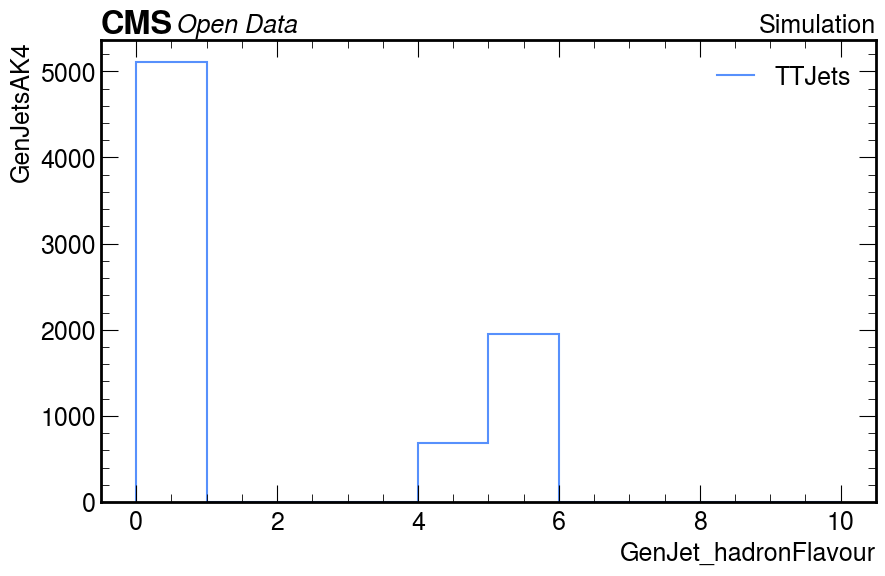

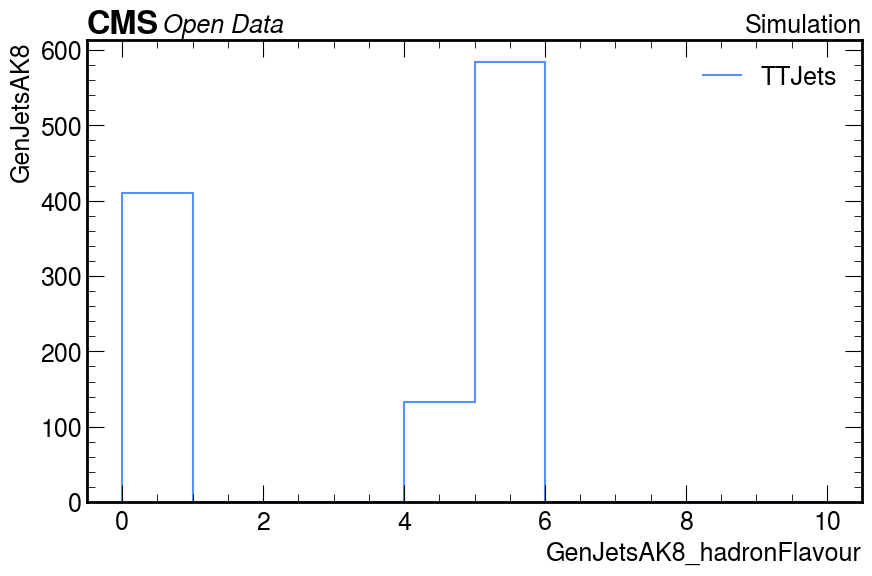

In [45]:
make_hist(GenJet_hadronFlavour, bins=10, range=(0,10), xlabel=r"GenJet_hadronFlavour", ylabel="GenJetsAK4", title="Simulation", label="TTJets", fname="TTToSemiLeptonic/GenJet_hadronFlavour.png", logy=False)
make_hist(GenJetsAK8_hadronFlavour, bins=10, range=(0,10), xlabel=r"GenJetsAK8_hadronFlavour", ylabel="GenJetsAK8", title="Simulation", label="TTJets", fname="TTToSemiLeptonic/GenJetsAK8_hadronFlavour.png", logy=False)